# Proyecto de Expected Loss Credit

URL: https://www.kaggle.com/datasets/db0boy/lending-club-loan-data-cleared/data

**Los marcados con negrita son los que tienen valores faltanes y nulos** <br><br>
'funded_amnt': The total amount committed to that loan at that point in time. <br>
'interest_rate', <br>
'monthly_payment', <br>
'grade', <br>
**'emp_title':** The job title supplied by the Borrower when applying for the loan. <br>
**'emp_length':** Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years. <br>
'home_ownership_status': The home ownership status provided by the borrower during registration. Our values are: RENT, OWN, MORTGAGE, OTHER. <br> 
'annual_income', <br>
'verification_status', <br> 
'loan_purpose', <br>
'addr_state', <br>
'dept_paym_income_ratio', <br> 
'num_30+_delinq_in_2yrs', <br>
'num_inq_in_6mths', <br>
**mths_since_last_delinq ,** The number of months since the borrower's last delinquency<br> 
'num_open_credit_lines', <br>
'num_derogatory_pub_rec', <br>
'total_credit_revolving_bal', <br>
'used_credit_share', <br>
'tot_num_credit_lines', <br>
'initial_list_status', <br>
'remaining_princ_for_tot_amnt_fund', <br> 
'paym_rec_for_tot_amnt_fund', <br>
'princ_rec', Incógnito ??<br>
'interest_rec', <br>
'late_fees_rec', <br>
**'num_open_trades_in_6mths':** Number of open trades in last 6 months <br> 
**'num_installment_acc_op_in_12mths'**, Number of installment accounts opened in past 12 months<br> 
**'num_installment_acc_op_in_24mths'**, Number of installment accounts opened in past 24 months <br>
**'mths_since_last_installment_acc_op'**, Months since most recent installment account opened<br>
**'num_rev_trades_op_in_12mths',** Number of revolving trades (operaciones de crédito renovable) opened in past 12 months<br>
**'num_rev_trades_op_in_24mths',** Number of revolving trades opened in past 24 months <br>
**'max_bal_owed',** Maximum current balance owed on all revolving accounts <br>
**'bal_to_cred_lim'**, Balance to credit limit on all trades <br>
**'num_inq'**, The number of inquiries in past 6 months (excluding auto and mortgage inquiries) <br>
'num_inq_in_12mths', <br> 
**'mths_since_recent_bankcard_delinq'**, Months since most recent bankcard opened delinquency.<br> 
**'mths_since_recent_revol_delinq'**, Months since most recent revolving (cts rotativas) delinquency. <br>
'disbursement_method', <br>
'loan_term_months', <br>
'issue_date_month', <br>
'issue_date_year', <br>
'region_code', <br>
'earliest_cr_line_month', The date month the borrower's earliest reported credit line was opened<br> 
'earliest_cr_line_year': The date year the borrower's earliest reported credit line was opened <br>

# 1. Recolección de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string as str

import os
import kagglehub

from scipy.stats import spearmanr

from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy.stats import chi2_contingency

c:\Users\USUARIO\Documents\GitHub\Expected_Credit_Loss\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# EJECUTAR UNA SOLA VEZ
# 1. Descargar la versión más reciente del dataset desde Kaggle
# kagglehub lo descarga en una caché local fuera de tu carpeta del proyecto
print("Descargando/Verificando dataset desde Kaggle...")
download_path = kagglehub.dataset_download("db0boy/lending-club-loan-data-cleared")
print(f"Los archivos están guardados en: {download_path}")

Descargando/Verificando dataset desde Kaggle...
Los archivos están guardados en: C:\Users\USUARIO\.cache\kagglehub\datasets\db0boy\lending-club-loan-data-cleared\versions\2

Cargando X.csv en memoria...
Cargando target.csv en memoria...

¡Datos listos para usar!


In [2]:
download_path="C:\\Users\\USUARIO\\.cache\\kagglehub\\datasets\\db0boy\\lending-club-loan-data-cleared\\versions\\2"

# 2. Construir las rutas hacia tus nuevos archivos Parquet mapeados en esa ruta
# (Ajusta los nombres exactos si dentro de la carpeta de Kaggle tienen mayúsculas o variaciones)
path_x = os.path.join(download_path, "X.csv")
path_target = os.path.join(download_path, "target.csv")

# 3. Cargar los datos directamente en dataframes de Pandas
print("\nCargando X.csv en memoria...")
data_x = pd.read_csv(path_x)

print("Cargando target.csv en memoria...")
data_y = pd.read_csv(path_target)

print("\n¡Datos listos para usar!")


Cargando X.csv en memoria...
Cargando target.csv en memoria...

¡Datos listos para usar!


In [3]:
data_x.info()

<class 'pandas.DataFrame'>
RangeIndex: 2139643 entries, 0 to 2139642
Data columns (total 45 columns):
 #   Column                              Dtype  
---  ------                              -----  
 0   funded_amnt                         int64  
 1   interest_rate                       float64
 2   monthly_payment                     float64
 3   grade                               str    
 4   emp_title                           str    
 5   emp_length                          str    
 6   home_ownership_status               str    
 7   annual_income                       float64
 8   verification_status                 str    
 9   loan_purpose                        str    
 10  addr_state                          str    
 11  dept_paym_income_ratio              float64
 12  num_30+_delinq_in_2yrs              int64  
 13  num_inq_in_6mths                    int64  
 14  mths_since_last_delinq              float64
 15  num_open_credit_lines               int64  
 16  num_derogat

In [4]:
# Cambio de tipo de datos de las columnas de texto a 'category'
cols_texto = data_x.select_dtypes(include=['object', 'string']).columns
data_x[cols_texto] = data_x[cols_texto].astype('category')

## 1. Limpieza y calidad de datos

Empezamos verificando las variables que tienen valores faltantes, necesitamos dar tratamiento o reemplazarlos

In [5]:
null_summary = (data_x.isna().sum().loc[lambda cantidad: cantidad > 0]/data_x.shape[0]) * 100
print(null_summary if len(null_summary) > 0 else "No hay valores nulos en el DataFrame.")

emp_title                              6.941672
emp_length                             6.091951
mths_since_last_delinq                50.989674
num_open_trades_in_6mths              40.457964
num_installment_acc_op_in_12mths      40.457964
num_installment_acc_op_in_24mths      40.457964
mths_since_last_installment_acc_op    42.308740
num_rev_trades_op_in_12mths           40.457964
num_rev_trades_op_in_24mths           40.457964
max_bal_owed                          40.457964
bal_to_cred_lim                       40.463526
num_inq                               40.457964
mths_since_recent_bankcard_delinq     76.811973
mths_since_recent_revol_delinq        67.015432
dtype: float64


Observamos que solamente las columnas emp_title y emp_length tienen un bajo porcentaje de missing values, alrededor de (6.9%), <br>
Pero el resto tiene de al menos el (40%) por lo tanto vamos a realizar un EDA de estas variables y saber con qué reemplazar los valores faltantes.

In [6]:
cantidad = len(data_x.isna().sum().loc[lambda cantidad: cantidad == 0])
print(f"Cantidad de columnas sin valores nulos: {cantidad} de un total de {data_x.shape[1]} columnas.")

Cantidad de columnas sin valores nulos: 31 de un total de 45 columnas.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    data_x,
    data_y.squeeze(),
    test_size=0.2,
    random_state=42,
    stratify=data_y.squeeze()
)

Separamos todo el dataset en Train y Test, porque se irá ya haciendo Feature Engineering a las variables y al hacerlas juntas a Test, el dataset ya se va "entrenando y aprendiendo" para el modelo, lo que genera Data Leakage.

## 2. Tramiento de valores faltantes (EDA previamente)

Empezamos con X_train a realizar todo del modelamiento; y esto empieza desde el tratamiento de datos.

Revisaremos las dos primeros variables categóricas <mark>'emp_title'</mark> y <mark>'emp_length'</mark>

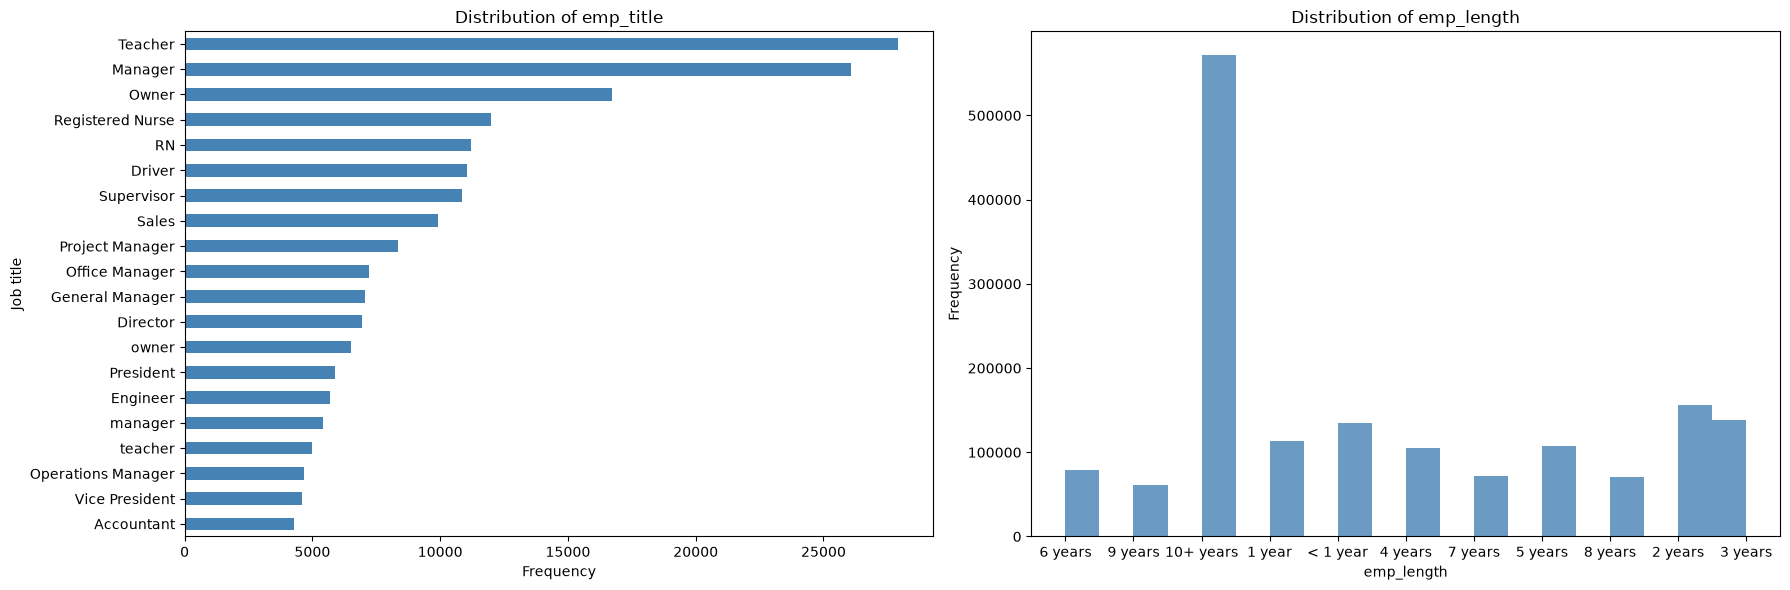

In [8]:
employment = ['emp_title', 'emp_length']

def plot_employment_distribution(X_train, employment):

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    for posicion, column in enumerate(employment):
        values = X_train[column].dropna()

        if column == 'emp_title':
            values.value_counts().head(20).sort_values().plot(
                kind='barh', ax=axes[posicion], color='steelblue'
            )
            axes[posicion].set_xlabel('Frequency')
            axes[posicion].set_ylabel('Job title')
        else:
            axes[posicion].hist(values, bins=20, color='steelblue', alpha=0.8)
            axes[posicion].set_xlabel(column)
            axes[posicion].set_ylabel('Frequency')

        axes[posicion].set_title(f'Distribution of {column}')

    plt.tight_layout()
    plt.show()

plot_employment_distribution(X_train, employment)

Vamos a normalizar todas las categorías de la variable en emp_title en minúscula porque hay combinaciones (Max y min) en las mismas palabras. Si existen NaN no es dable decir que se puede reemplazar por la moda, podría ser desempleado, entonces podemos descartar esta columna o crear una columna extra de 'sin_emp_title'

También vamos a reemplazar las variables emp_length en tiempo de empleo en años. En vez de categórica se usa mejor una transformación numérica y se adiciona una columna binaria 'con_empleo', para que el modelo pueda responder de forma lineal en conjunto a 'con_empleo', también NaN podría significar sin empleo de acuerdo al dataset o explicación del negocio, por lo tanto se colocaría 0 o 1.

In [9]:
mapa = {'10+ years': 10, '9 years': 9, '8 years': 8, '7 years': 7, '6 years': 6, '5 years': 5, '4 years': 4,
        '3 years': 3, '2 years': 2, '1 year': 1, '< 1 year': 0.5
}

X_train['emp_length_num'] = X_train['emp_length'].map(mapa)
X_train['emp_length_num'] = X_train['emp_length_num'].astype(float)
X_train['emp_length_num'] = X_train['emp_length_num'].fillna(0)

# Eliminamos la columna inicial 'emp_length'
X_train.drop(columns=['emp_length'], inplace=True)

La mayoría de personas sí tiene empleo y tiene una mayoría trabajando más de 10 años.

Ahora vamos a crear una lista de distribución de las variables que tienen valores faltantes (NaN):

- mths_since_last_delinq <br>                
- num_open_trades_in_6mths <br>             
- num_installment_acc_op_in_12mths <br>      
- num_installment_acc_op_in_24mths <br>      
- mths_since_last_installment_acc_op <br>   
- num_rev_trades_op_in_12mths <br>           
- num_rev_trades_op_in_24mths <br>          
- max_bal_owed <br>                          
- bal_to_cred_lim <br>                      
- num_inq <br>                               
- mths_since_recent_bankcard_delinq <br>     
- mths_since_recent_revol_delinq

In [10]:
columns_na_to_plot = null_summary.index.to_list()[2::] #Evitamos usar los dos primeros features: 'emp_title' y 'emp_length_num'
#columns_na_to_plot 

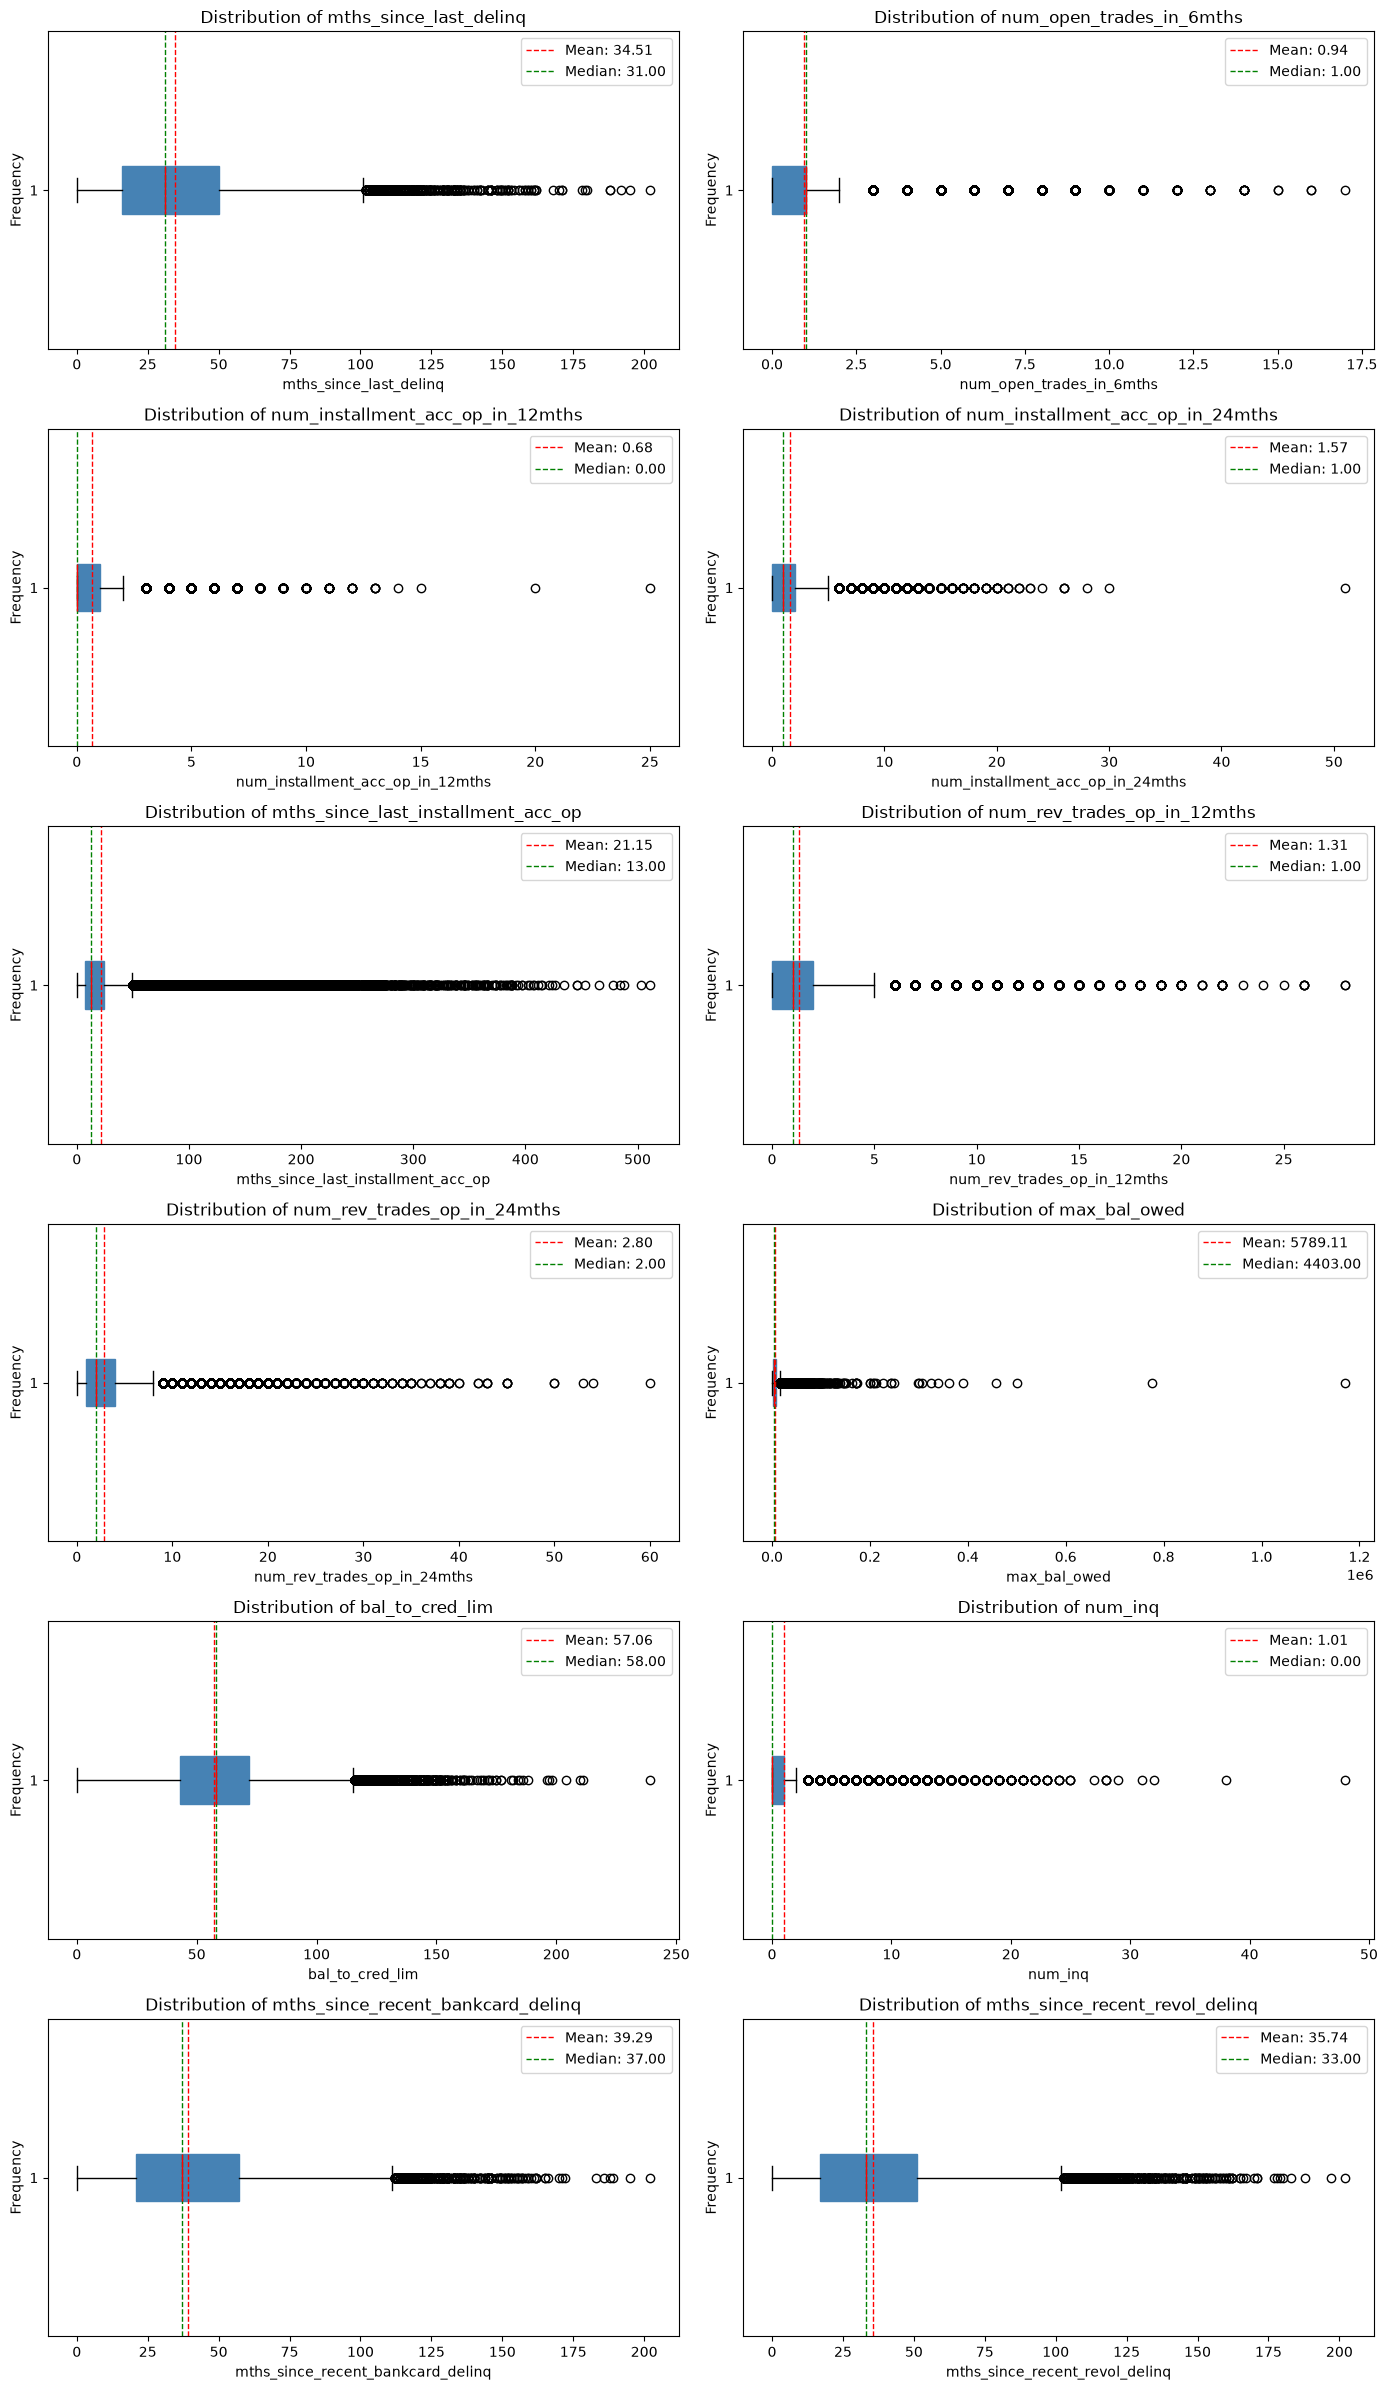

In [11]:
def plot_distribution_num(X_train, columns_na_to_plot):
        fig, axes = plt.subplots(6, 2, figsize=(14, 24))
        axes = axes.flatten() #Aplana una salida de 2D a 1D para facilitar la iteración

        for posicion, columna in enumerate(columns_na_to_plot):
                #axes[posicion].hist(X_train[columna].dropna(), bins=30, color='blue', alpha=0.7)
                axes[posicion].boxplot(X_train[columna].dropna(), orientation='horizontal', patch_artist=True, 
                                        boxprops=dict(facecolor='steelblue', color='steelblue'), 
                                        medianprops=dict(color='red'))
                axes[posicion].set_xlabel(columna)
                axes[posicion].set_ylabel('Frequency')
                axes[posicion].set_title(f'Distribution of {columna}')

                mean = X_train[columna].mean()
                median = X_train[columna].median()
                axes[posicion].axvline(
                        mean, color='red', linestyle='dashed', linewidth=1,
                        label=f'Mean: {mean:.2f}')
                axes[posicion].axvline(
                        median, color='green', linestyle='dashed', linewidth=1,
                        label=f'Median: {median:.2f}')
                axes[posicion].legend()

        plt.tight_layout()
        plt.show()

plot_distribution_num(X_train, columns_na_to_plot)

### Tratamiento de inconsistencias con sentido de lógica

Para el tratamiento a las variables: 

- mths_since_last_delinq --> nunca_delinq
- mths_since_last_installment_acc_op --> nunca_last_install
- mths_since_recent_bankcard_delinq --> nunca_last_bankcard_delinq
- mths_since_recent_revol_delinq --> nunca_last_revol_delinq

Vamos a añadir una columna <mark>'flag binario'</mark> sobre **si sucedió o no sucedió** un incedente por lo que es mejor llenarlo con 0 a con un promedio y luego llenamos esas filas con **valores centinela como: 999 meses**, que significa que si nunca sucedió, probablemente sucedió mucho tiempo atrás, entonces se coloca ese valor. Ya que al si colocaramos un valor medio serían valores falseados de meses de incidencia que va a afectar a modelo logístico y lineal.

In [12]:
X_train['nunca_delinq'] = X_train['mths_since_last_delinq'].isna().astype(int)
X_train['nunca_last_install'] = X_train['mths_since_last_installment_acc_op'].isna().astype(int)
X_train['nunca_last_bankcard_delinq'] = X_train['mths_since_recent_bankcard_delinq'].isna().astype(int)
X_train['nunca_last_revol_delinq'] = X_train['mths_since_recent_revol_delinq'].isna().astype(int)

También vamos a eliminar a la variable 'emp_title' ya que no aporta mucho el título universitario en el score crediticio sino si tiene empleo o no con 'sin_emp_title'. 

In [13]:
#X_train['emp_title'] = X_train['emp_title'].str.strip().str.lower()
X_train['sin_emp_title'] = X_train['emp_title'].isna().astype(int)
X_train.drop(columns=['emp_title'], inplace=True)

In [14]:
centinela = 999
X_train['mths_since_last_delinq'] = X_train['mths_since_last_delinq'].fillna(centinela)

X_train['mths_since_last_installment_acc_op'] = X_train['mths_since_last_installment_acc_op'].fillna(centinela)
X_train['mths_since_recent_bankcard_delinq'] = X_train['mths_since_recent_bankcard_delinq'].fillna(centinela)
X_train['mths_since_recent_revol_delinq'] = X_train['mths_since_recent_revol_delinq'].fillna(centinela)

El siguiente grupo de variables: 

- num_open_trades_in_6mths, 
- num_installment_acc_op_in_12mths, 
- num_installment_acc_op_in_24mths, 
- num_rev_trades_op_in_12mths, 
- num_rev_trades_op_in_24mths, 
- num_inq. 

Aquí lo correcto es **imputar con un valor 0** (como la media de num_inq), porque es posible que nunca se abrieron cuentas ni tuvieron consultas. Por el contrario colocar un valor medio, estoy diciendo que hubo actividad, y el coeficiente se sesga con una relación más débil hacia el target.

In [15]:
X_train['num_open_trades_in_6mths'] = X_train['num_open_trades_in_6mths'].fillna(0)
X_train['num_installment_acc_op_in_12mths'] = X_train['num_installment_acc_op_in_12mths'].fillna(0)
X_train['num_installment_acc_op_in_24mths'] = X_train['num_installment_acc_op_in_24mths'].fillna(0)
X_train['num_rev_trades_op_in_12mths'] = X_train['num_rev_trades_op_in_12mths'].fillna(0)
X_train['num_rev_trades_op_in_24mths'] = X_train['num_rev_trades_op_in_24mths'].fillna(0)
X_train['num_inq'] = X_train['num_inq'].fillna(0)

Reemplazamos luego las variables: <mark>max_bal_owed</mark> por la mediana ya que la distribución algo más asimétrica y <mark>bal_to_cred_lim</mark> por la media

In [16]:
X_train['max_bal_owed'] = X_train['max_bal_owed'].fillna(X_train['max_bal_owed'].median())
X_train['bal_to_cred_lim'] = X_train['bal_to_cred_lim'].fillna(X_train['bal_to_cred_lim'].mean())

Revisemos nuevamente la nueva distribución boxplot de las variables imputadas

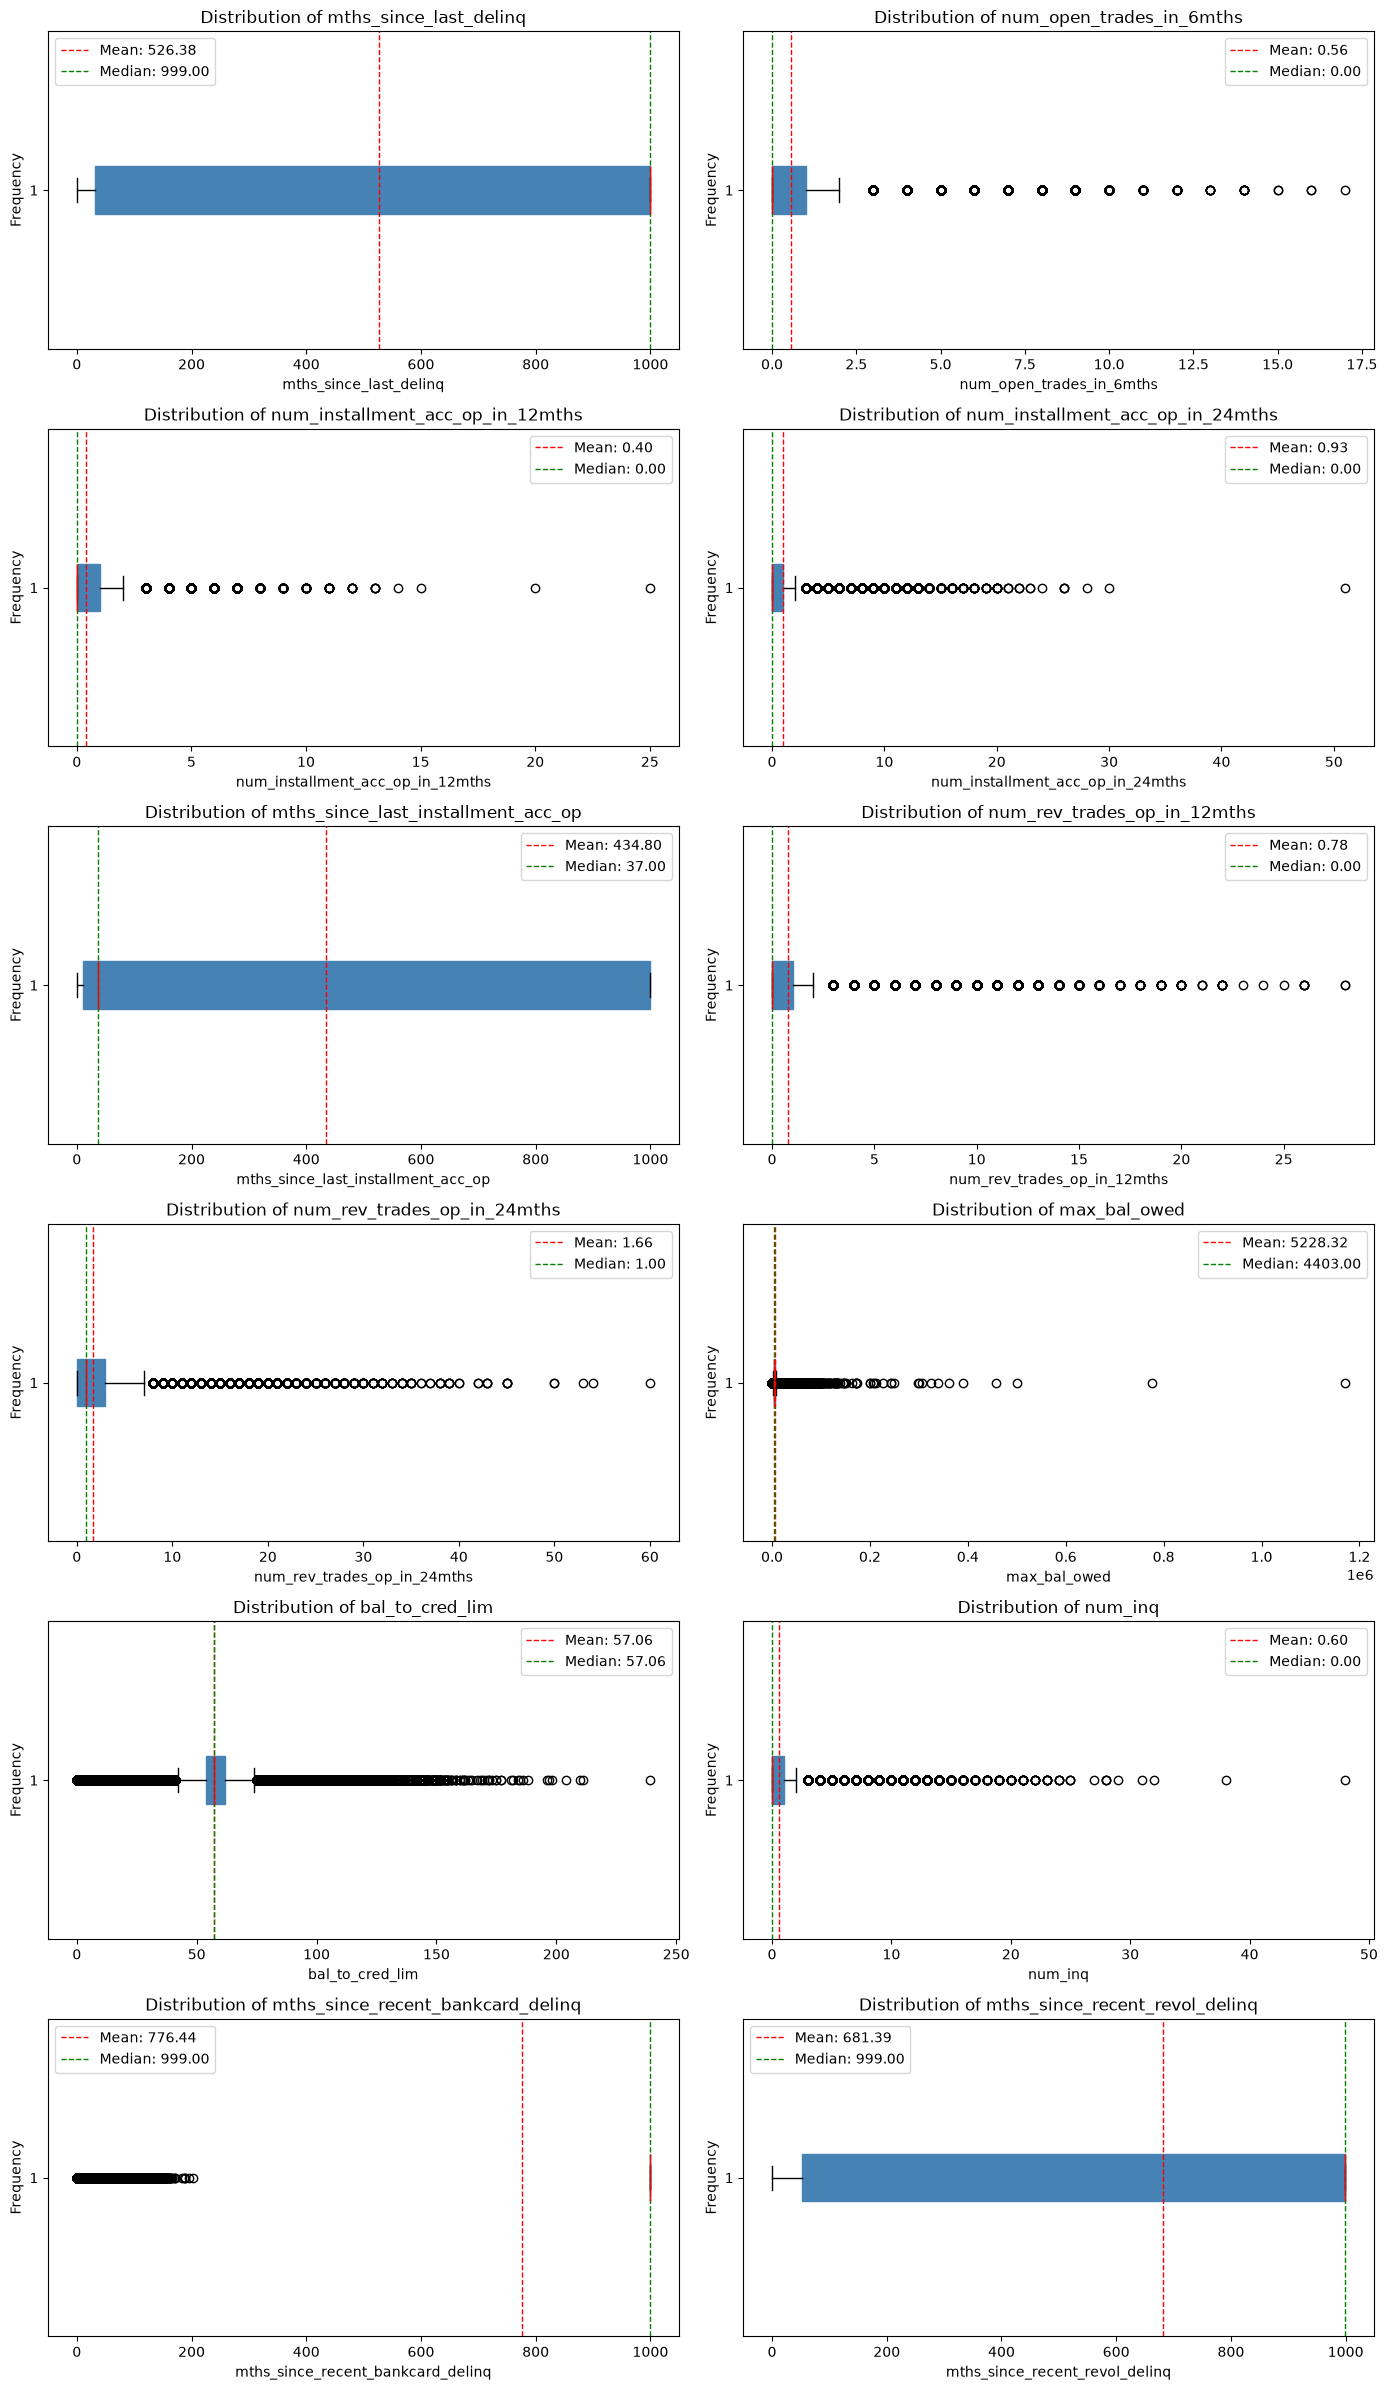

In [17]:
plot_distribution_num(X_train, columns_na_to_plot)

### Revisión final de valores faltantes

In [18]:
null_summary = (X_train.isna().sum().loc[lambda cantidad: cantidad > 0]/X_train.shape[0]) * 100
print(null_summary if len(null_summary) > 0 else "No hay valores nulos en el DataFrame.")

No hay valores nulos en el DataFrame.


Ya no tenemos valores faltantes dentro del DataFrame

### 2.2 Análisis Exploratorio para Detección de Outliers

Se realizará un análisis de outliers mediante gráficas Boxplot

In [19]:
#columnas numericas
X_train.select_dtypes(include=[np.number]).columns

Index(['funded_amnt', 'interest_rate', 'monthly_payment', 'annual_income',
       'dept_paym_income_ratio', 'num_30+_delinq_in_2yrs', 'num_inq_in_6mths',
       'mths_since_last_delinq', 'num_open_credit_lines',
       'num_derogatory_pub_rec', 'total_credit_revolving_bal',
       'used_credit_share', 'tot_num_credit_lines',
       'remaining_princ_for_tot_amnt_fund', 'paym_rec_for_tot_amnt_fund',
       'princ_rec', 'interest_rec', 'late_fees_rec',
       'num_open_trades_in_6mths', 'num_installment_acc_op_in_12mths',
       'num_installment_acc_op_in_24mths',
       'mths_since_last_installment_acc_op', 'num_rev_trades_op_in_12mths',
       'num_rev_trades_op_in_24mths', 'max_bal_owed', 'bal_to_cred_lim',
       'num_inq', 'num_inq_in_12mths', 'mths_since_recent_bankcard_delinq',
       'mths_since_recent_revol_delinq', 'loan_term_months', 'issue_date_year',
       'region_code', 'earliest_cr_line_year', 'emp_length_num',
       'nunca_delinq', 'nunca_last_install', 'nunca_last_bankc

Tenemos estas variables numéricas pero pondremos a un lado a las variables binarias y obtendremos una distribución BoxPlot de las demás

In [20]:
cols_numeric = X_train.select_dtypes(include=[np.number]).columns.to_list()[0:-5]

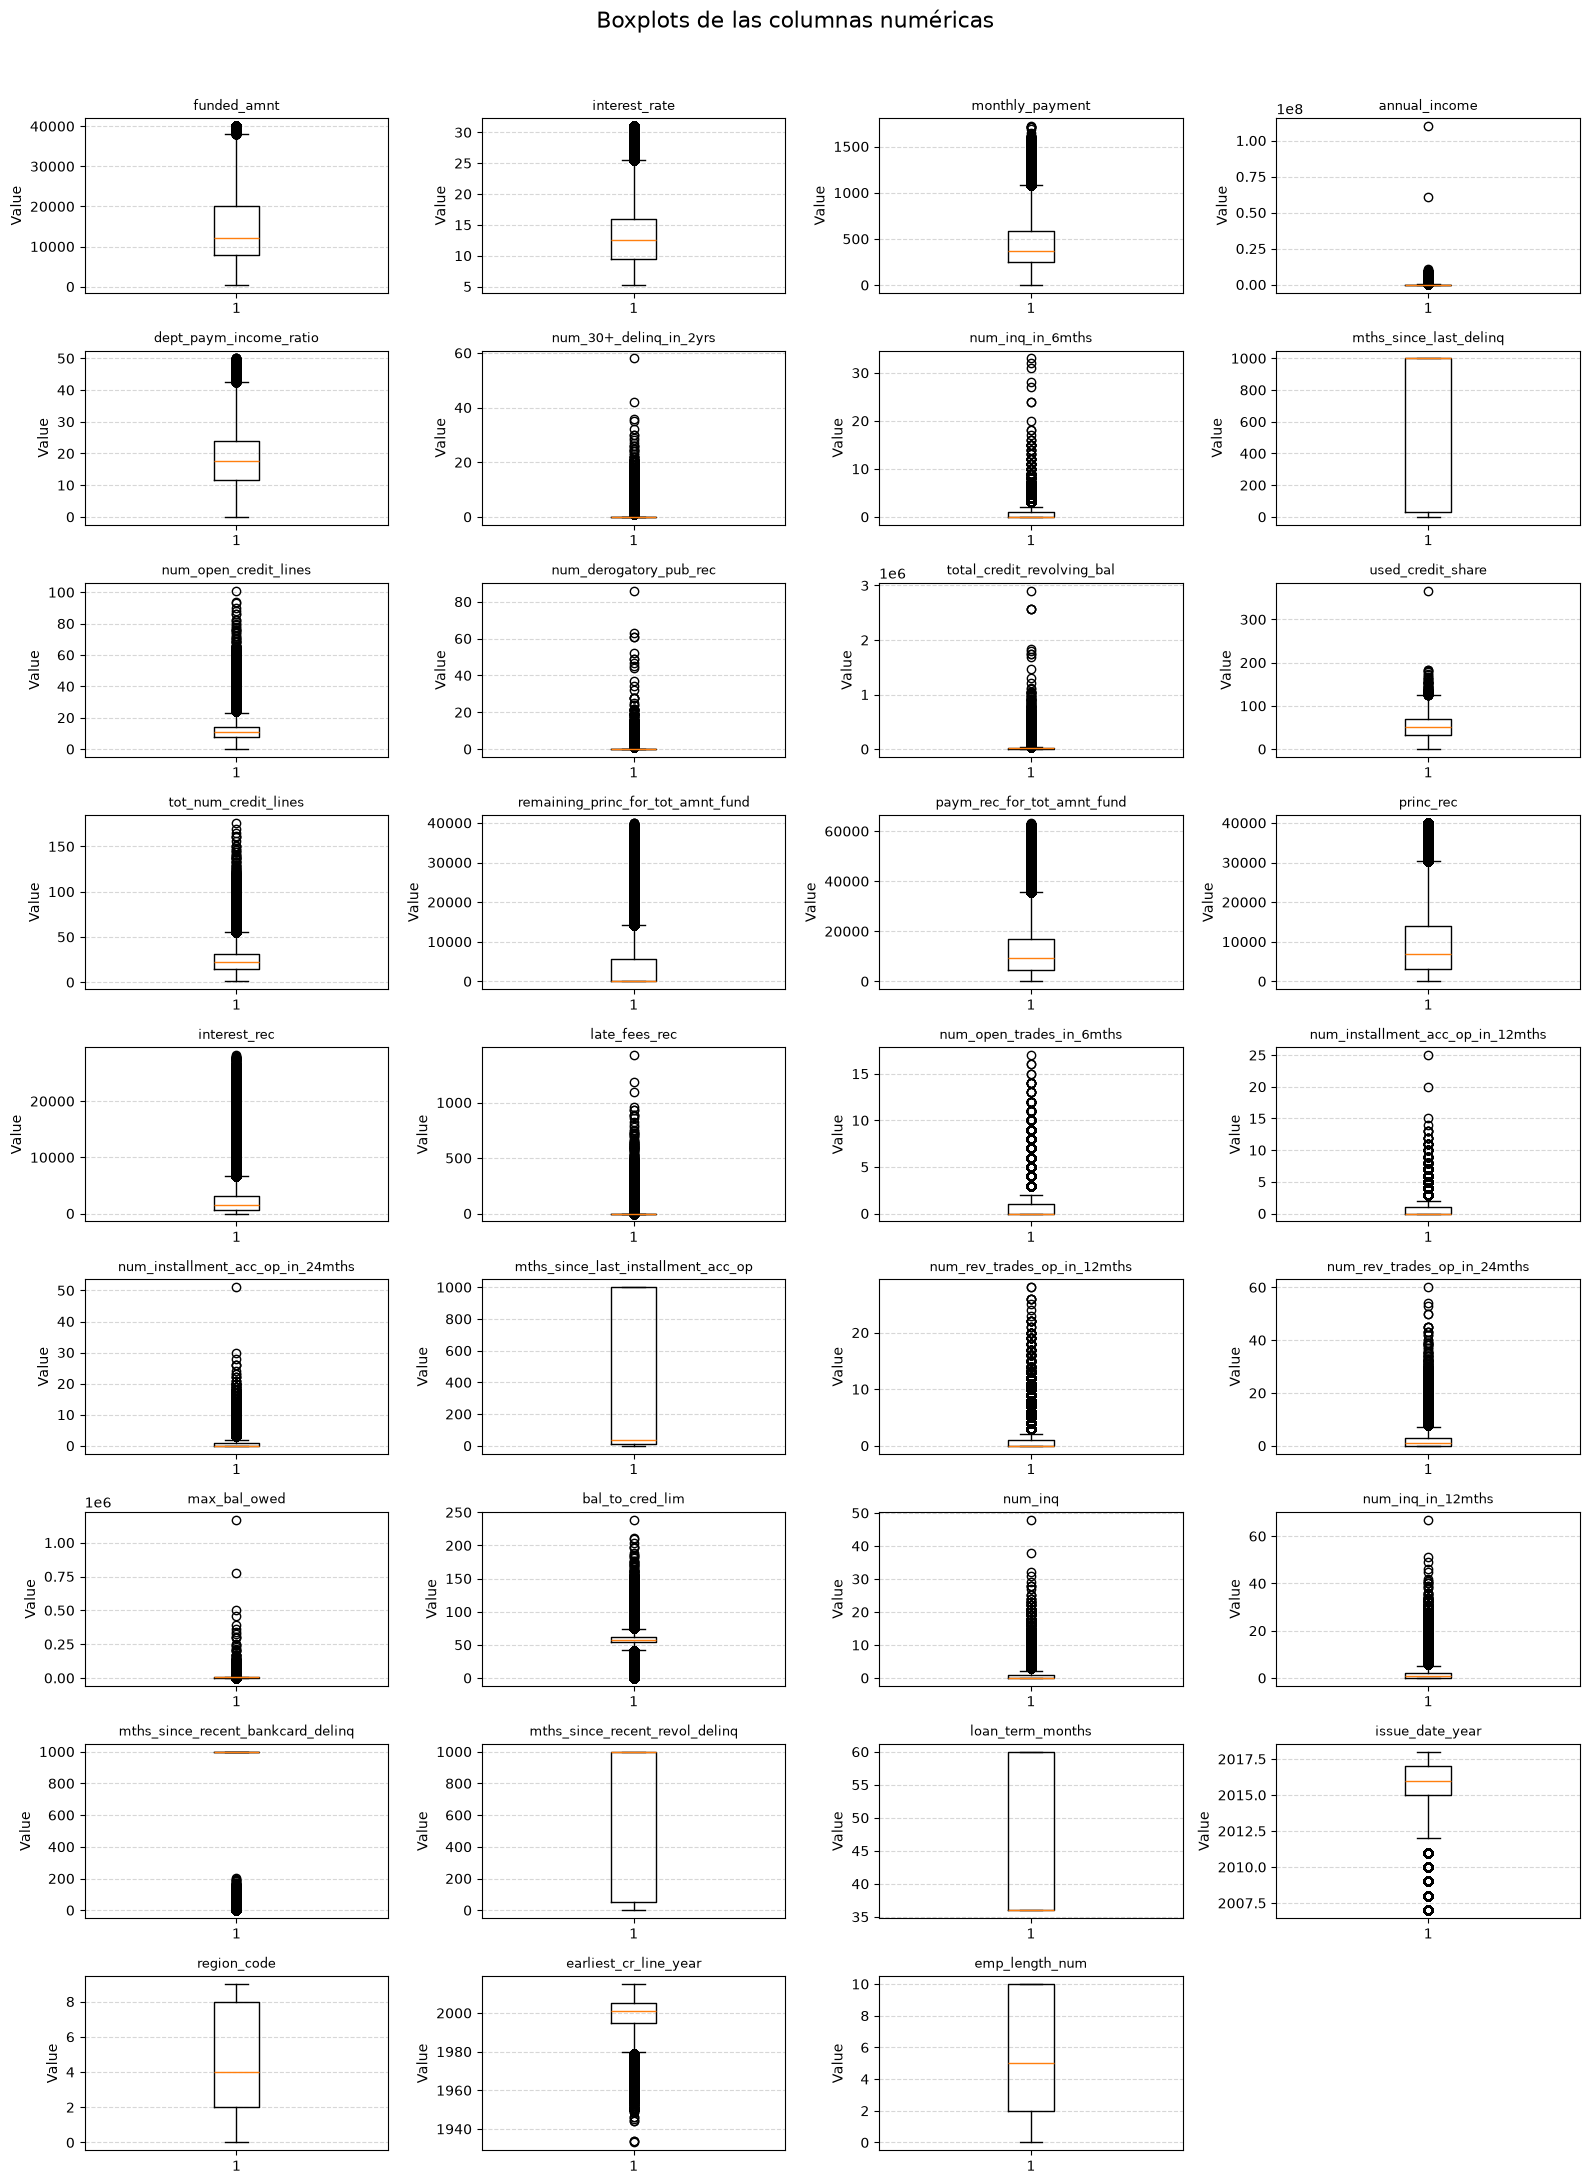

In [21]:
boxplot_columns = cols_numeric

fig, axes = plt.subplots(10, 4, figsize=(16, 24))
axes = axes.flatten()

for posicion, column in enumerate(boxplot_columns):
    axes[posicion].boxplot(
        X_train[column].dropna(), orientation='vertical'
    )
    axes[posicion].set_title(column, fontsize=9)
    axes[posicion].set_ylabel('Value')
    axes[posicion].grid(axis='y', linestyle='--', alpha=0.5)

for axis in axes[len(boxplot_columns):]:
    axis.set_visible(False)

fig.suptitle('Boxplots de las columnas numéricas', fontsize=16, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Criterios de Imputación

1. Las variables: 
- mths_since_last_delinq, 
- mths_since_last_installment_acc_op, 
- mths_since_recent_bankcard_delinq, 
- mths_since_recent_revol_delinq <br><br>
Poseen valores centinela 999 meses, que hablan de tiempos bastante pasado y que al recortarlos el algoritmo perderá este valor y se moverá hacia más abajo, se perdería la definición previa, sobre que si nunca sucedió un incidente (0) proabablemente sucedió mucho tiempo atrás. **Por lo tanto estas variables se mantienen**

2. Las variables: 
- num_30+_delinq_in_2yrs, 
- num_derogatory_pub_rec, 
- num_inq, 
- num_inq_in_6mths, 
- num_inq_in_12mths, 
- num_installment_acc_op_in_12/24mths, 
- num_open_trades_in_6mths, 
- num_rev_trades_op_in_12/24mths. <br><br>
También la vamos a dejar **sin modificación** porque son números de morosidad, y aplicar recortes por: winsor o capping perdería la información. En todo caso se puede aplicar un recorte por Winsorización de 99% para ajustar el modelo.

3. Estas variables: 
- funded_amnt, 
- interest_rate, 
- monthly_payment, 
- princ_rec, 
- interest_rec, 
- remaining_princ_for_tot_amnt_fund, 
- paym_rec_for_tot_amnt_fund.<br><br> Tienen una distribución continua casi simétrica y aquí si conviene usar capping: **1.5xIQR**

In [22]:
# Capping de outliers usando el método del IQR
def outliers_iqr_capping(train_df, columns, k=1.5):
    Q1 = train_df[column].quantile(0.25)
    Q3 = train_df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR

    # Tratamiento de los outliers mediante anidación de funciones np.where (condición, valor_si_es_verdadero, valor_si_es_falso)
    train_df[column] = np.where(train_df[column] < lower_bound, 
                          lower_bound, 
                          np.where(train_df[column] > upper_bound, 
                                   upper_bound, train_df[column]))

columns = ['funded_amnt', 
           'interest_rate', 
           'monthly_payment', 
           'princ_rec', 
           'interest_rec', 
           'remaining_princ_for_tot_amnt_fund', 
           'paym_rec_for_tot_amnt_fund'
           ]

outliers_iqr_capping(X_train, columns, k=1.5)

También 'anual_income' tiene dos outliers demasiado altos, por encima de $ 1M, por lo tanto vamos a verificar si tiene sesgo hacia la clase (+) de default, evaluando sus proporciones respecto al total. Si tiene un alto sesgo eliminamos lo valores atípicos, si no los mantenemos dentro del dataset

In [23]:
# Unimos los dos datasets X y Y
train_df = X_train.merge(y_train, left_index=True, right_index=True, how='outer')

In [24]:
test_df = X_test.merge(y_test, left_index=True, right_index=True, how='outer')

In [25]:
# ¿Cuántos registros tienen ingresos claramente implausibles?
umbral_sospechoso = 1_000_000  # $1M anual, ya es raro para el perfil típico de este dataset
sospechosos_mas1M = X_train[X_train['annual_income'] > umbral_sospechoso]
print("Cantidad máxima de outliers > $1M:", len(sospechosos_mas1M))

Cantidad máxima de outliers > $1M: 460


In [26]:
sospechosos_mas1M = train_df[train_df['annual_income'] > 1_000_000]
print(sospechosos_mas1M['y'].value_counts(normalize=True))
print(train_df['y'].value_counts(normalize=True))  # para comparar contra la tasa base

y
0    0.921739
1    0.078261
Name: proportion, dtype: float64
y
0    0.86927
1    0.13073
Name: proportion, dtype: float64


Al calcular la proporción de valores > $1M respecto a la clase positiva y negativa. Y también de la clase (+) y (-) respecto a todo el dataset. <br>Los resultados nos muestran solo una diferencia de 5%, es decir mantiene casi una similar proporción los datos atípicos con respecto a los de clase positiva. 

Prueba de hipótesis **p-value**

In [27]:
from statsmodels.stats.proportion import proportions_ztest

count = sospechosos_mas1M['y'].sum()  # positivos en el grupo sospechoso
nobs = len(sospechosos_mas1M)
count_base = train_df['y'].sum()
nobs_base = len(train_df)

stat, p = proportions_ztest([count, count_base], [nobs, nobs_base])
print(p)

0.0008439415265846821


Hacemos por otro lado, una prueba de hipótesis p-value para saber si en efectivo esta proporción de outliers está relacionada con la clase positiva. Ho=No tiene relación o efecto Ha=Tiene relación o efecto. El p-value=0.003 < 0.05 entonces se rechaza la hipótesis nula. 

Lo que dice que si hay relación, pero al ser una proporción de 574 vs 2,139,643 registros, podríamos eliminar la fila 'annual_income'. Pero para nuestro criterio mejor las mantenemos porque puede funcionar para el algoritmo.

4. Las últimas variables son discretas: 

- 'issue_date_month', <br>
- 'issue_date_year', <br>
- 'region_code', <br>
- 'earliest_cr_line_month', <br> 
- 'earliest_cr_line_year' <br>

Por lo tanto no necesitan tratamiento de outliers. Solamente visualizaremos la distribución de las variables 'issue_date_year' y 'earliest_cr_line_year'

In [28]:
date_cols = ['issue_date_month', 'issue_date_year', 
             'earliest_cr_line_year','earliest_cr_line_month', 
            'region_code', 'y']

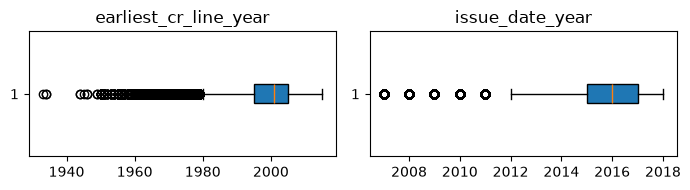

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(7, 2))

axes[0].boxplot(train_df['earliest_cr_line_year'].dropna(), orientation='horizontal', patch_artist=True,)
axes[0].set_title('earliest_cr_line_year')

axes[1].boxplot(train_df['issue_date_year'].dropna(), orientation='horizontal', patch_artist=True,)
axes[1].set_title('issue_date_year')

plt.tight_layout()
plt.show()

## 3. Relación entre variables (EDA)
Visualización y análisis exploratorio. Relaciones entre variables y default, y entre variables y pérdida.

En esta etapa haremos las siguiente ruta de trabajo:

(3.1	Limpiar late_fees_rec (clip a 0) y revisar el -1 de dept_paym_income_ratio) <br>
3.1 EDA categórica vs numérica <br>
3.2	Calcular IV/WOE por variable (ranking principal de poder predictivo) <br>
3.3	Spearman entre numéricas (multicolinealidad) <br>
3.4	Mann-Whitney U + tamaño de efecto para numéricas vs y (excluyendo sentinelas) Nota: similar a Spearman <br>
3.5	Chi² + Cramér's V para categóricas/flags vs y <br>
3.6	Kruskal-Wallis para categórica vs numérica (exploratorio) <br>
3.7	Corrección FDR sobre todos los p-valores <br>
3.8	Seleccionar features combinando IV + tamaño de efecto + criterio de negocio (no solo p-valor) <br>

#### Descripción de variables categóricas

In [30]:
train_df.select_dtypes(exclude=[np.number]).describe().T.sort_index()

,count,unique,top,freq
addr_state,1711714,51,CA,240672
disbursement_method,1711714,2,Cash,1653202
earliest_cr_line_month,1711714,12,Aug,172052
grade,1711714,35,C1,110270
home_ownership_status,1711714,4,MORTGAGE,824977
initial_list_status,1711714,2,w,1145827
issue_date_month,1711714,12,Oct,172871
loan_purpose,1711714,14,debt_consolidation,965202
verification_status,1711714,3,Source Verified,681534


En esta descripción podemos ver que los mayores prestamistas son managers de 10 años de experiencia y su motivo de crédito es de tipo HIPOTECA. 

#### Descripción de variables numéricas

In [31]:
train_df.select_dtypes(include=[np.number]).describe().T.sort_index()

,count,mean,std,min,25%,50%,75%,max
annual_income,1711714.0,78970.022606,122054.060402,1.900000e+03,47303.2500,65134.500000,95000.000000,1.100000e+08
bal_to_cred_lim,1711714.0,57.055587,16.100375,0.000000e+00,54.0000,57.055587,62.000000,2.390000e+02
dept_paym_income_ratio,1711714.0,18.087483,8.421449,0.000000e+00,11.7700,17.590000,24.030000,4.996000e+01
earliest_cr_line_year,1711714.0,1999.395957,7.833571,1.933000e+03,1995.0000,2001.000000,2005.000000,2.015000e+03
emp_length_num,1711714.0,5.646758,3.802959,0.000000e+00,2.0000,5.000000,10.000000,1.000000e+01
funded_amnt,1711714.0,14783.143022,9031.904858,5.000000e+02,8000.0000,12250.000000,20000.000000,4.000000e+04
interest_rate,1711714.0,13.058979,4.794735,5.310000e+00,9.4900,12.620000,15.880000,3.099000e+01
interest_rec,1711714.0,2397.623408,2687.469706,0.000000e+00,694.2200,1484.300000,3058.302500,2.819250e+04
issue_date_year,1711714.0,2015.765516,1.792385,2.007000e+03,2015.0000,2016.000000,2017.000000,2.018000e+03
late_fees_rec,1711714.0,1.439991,11.310180,-9.500000e-09,0.0000,0.000000,0.000000,1.427250e+03


### 3.1 EDA categórica vs numérica

#### Columnas Num vs. Target

In [32]:
train_df_nums = train_df.filter(regex=r'^num_')
train_df_mths = train_df.filter(regex=r'^mths_')

In [33]:
print(enumerate(train_df.columns.to_list()))

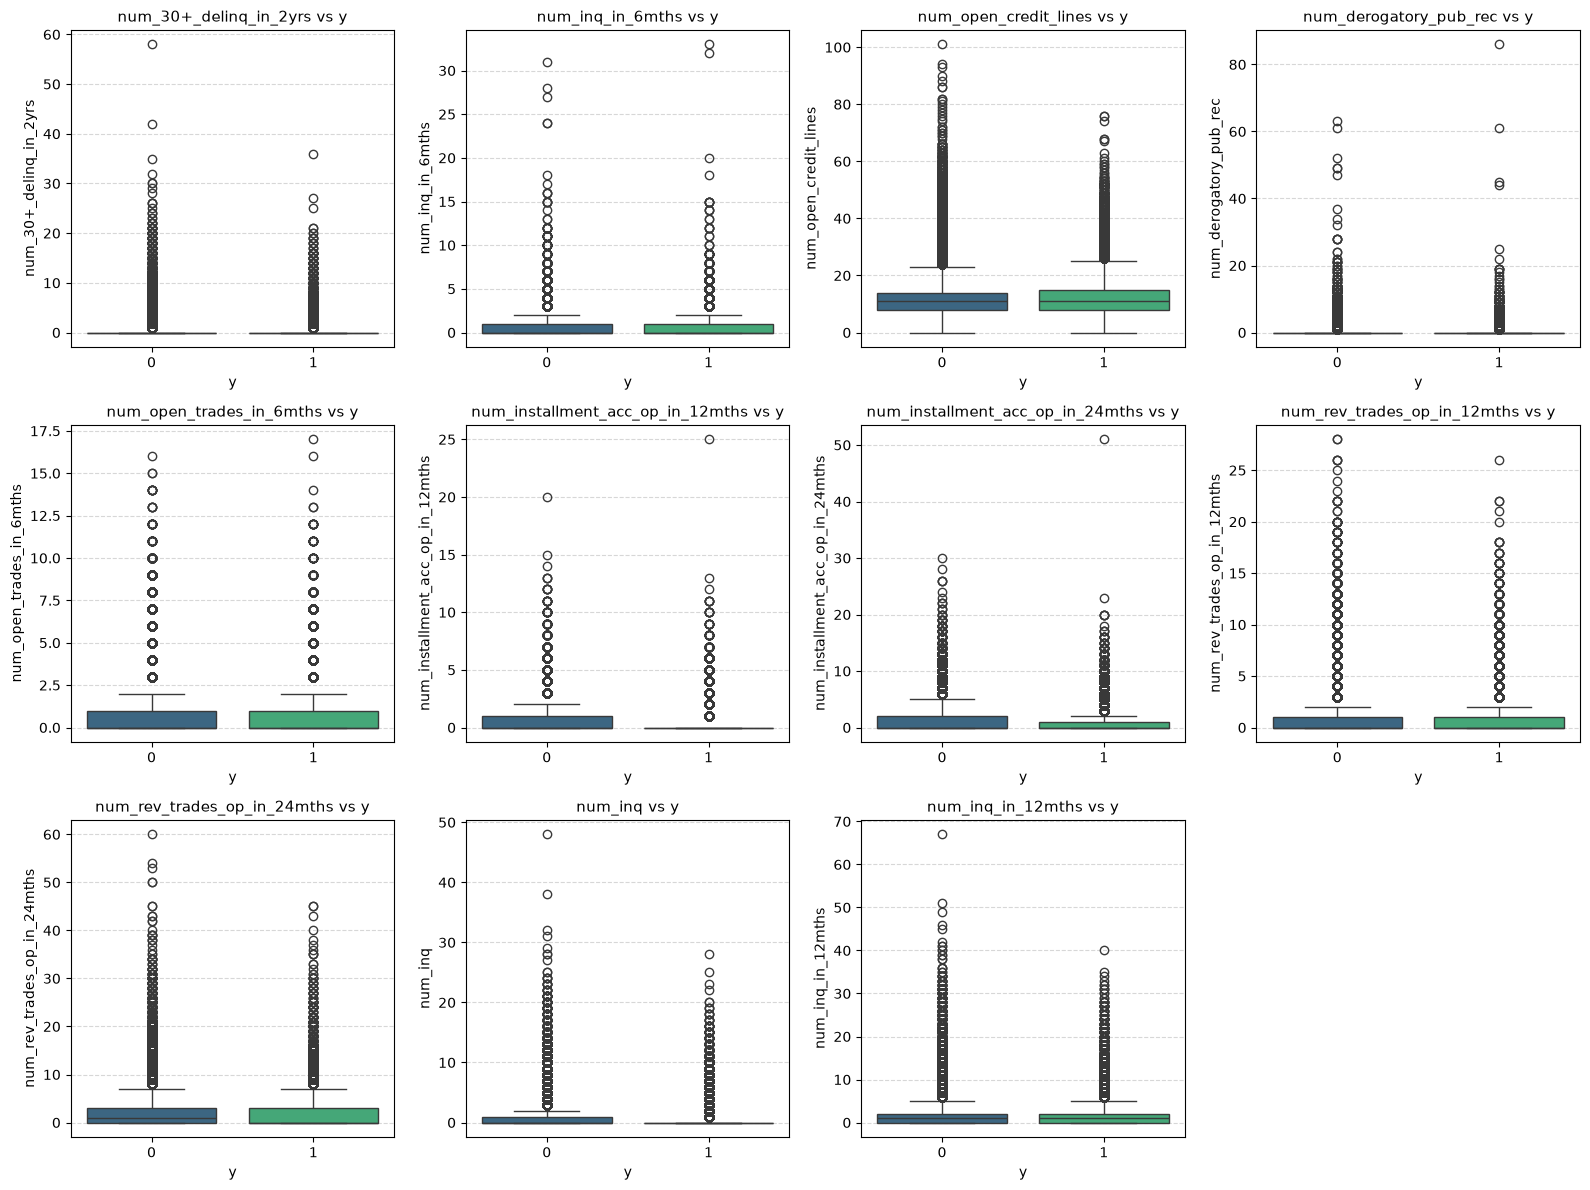

In [34]:
def plot_boxplots_by_target(train_df, train_df_nums, target):

    num_cols_all = train_df_nums.columns.to_list()

    num_cols_all = [c for c in num_cols_all if c != target]  # el target no se compara consigo mismo

    n_cols = 4
    n_rows = int(np.ceil(len(num_cols_all) / n_cols))
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols_all):
        sns.boxplot(data=train_df, x=target, y=col, ax=axes[i], hue=target, legend=False, palette='viridis')
        axes[i].set_title(f'{col} vs {target}', fontsize=11)
        axes[i].grid(axis='y', linestyle='--', alpha=0.5)

    # Apagar subplots sobrantes si el número de columnas no llena la cuadrícula
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_boxplots_by_target(train_df, train_df_nums, 'y')

En las aperturas de cuentas a plazo fijo ('installment_account') es posible que haya habido fuga de datos (leakage) porque al abrir más cuentas es más posible de darse el default, más riesgo. Pero al no saber el origen de los datos asumiremos que son datos correctos.

#### Columnas 'months' vs. Target(Default)

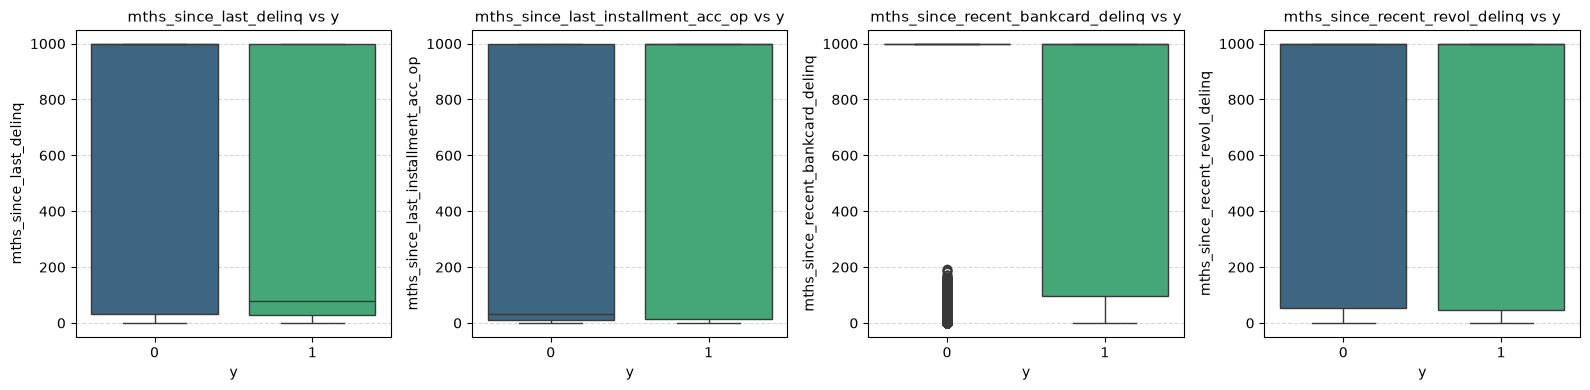

In [35]:
plot_boxplots_by_target(train_df, train_df_mths, 'y')

Observamos que la columna 'mths_since_recent_bankcard_delinq' tiene una concentración de valores en la clase default (+), pero observaremos en un histograma a qué se debe

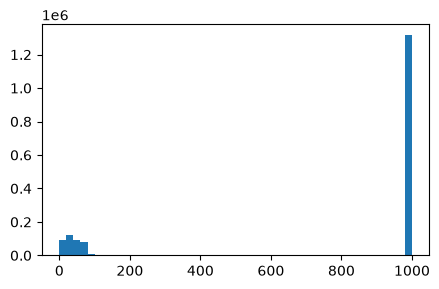

In [36]:
plt.figure(figsize=(5, 3))
plt.hist(train_df['mths_since_recent_bankcard_delinq'], bins=50)
plt.show()

Se debe a la concentración de registros en las centinelas = 999

In [37]:
col = 'mths_since_recent_bankcard_delinq'

# Agrupar los meses y conservar 999 como categoría independiente
grupos = pd.cut(
    train_df[col].where(train_df[col] != 999),
    bins=[-np.inf, 12, 24, 48, 998],
    labels=['0–12', '13–24', '25–48', '49+']
).astype('object')

grupos = grupos.fillna('Sin registro (999)')

# Porcentaje de y=0 e y=1 dentro de cada grupo
proporcion_target = pd.crosstab(grupos, train_df['y'], normalize='index').mul(100)
proporcion_target.columns = [f'y={valor} (%)' for valor in proporcion_target.columns]

proporcion_target

,y=0 (%),y=1 (%)
mths_since_recent_bankcard_delinq,,
0–12,85.115086,14.884914
13–24,85.582914,14.417086
25–48,86.524250,13.475750
49+,85.612245,14.387755
Sin registro (999),87.246324,12.753676


En esta tabla vemos que los valores centinela = 999 (ya con registro) tienen más proporción (87.24%) en el target de 'no morosidad' a diferencia del resto que cae en morosidad pero de ellos es apenas el (12.7%). Esto muestra una mejor claridad a diferencia de lo que el boxplot de esta variable nos dice respecto al target, que había más concentración en morosidad.


Verificaremos ahora si hay saltos abruptos que dependen desde la originación de datos entre columnas que registran consultas o meses desde la última mora en 'mths_since_recent_bankcard_delinq'

In [38]:
# Si estas variables realmente dependen del momento de originación,
# su distribución NO debería tener una relación artificial con issue_date_year
# (más allá de tendencias macro normales del buró de crédito)
train_df.groupby('issue_date_year')[['num_inq_in_6mths', 'mths_since_recent_bankcard_delinq']].median()

,num_inq_in_6mths,mths_since_recent_bankcard_delinq
issue_date_year,,
2007,1.0,999.0
2008,1.0,999.0
2009,1.0,999.0
2010,1.0,999.0
2011,0.0,999.0
2012,1.0,999.0
2013,0.0,999.0
2014,0.0,999.0
2015,0.0,999.0


Ahora comprobamos que no hay saltos abruptos entre ambas columnas y se va sosteniendo en el tiempo, entonces no hay otra incosistencia que afecte al dataset.

### 3.2	Calcular IV/WOE por variable (ranking principal de poder predictivo) <br>

Para regresión logística con target binario, la industria de riesgo crediticio no usa típicamente ANOVA/chi² como criterio principal — usa Weight of Evidence (WOE) e Information Value (IV) por variable, que:<br><br>
Funciona igual de bien para numéricas y categóricas (discretizando las numéricas en bins).
Da un ranking directo de poder predictivo (IV < 0.02 = inútil, 0.02-0.1 = débil, 0.1-0.3 = medio, 0.3-0.5 = fuerte, >0.5 = sospechoso de leakage).
Es literalmente lo que se usará para transformar las variables antes de meterlas al modelo (WOE-encoding), así que se mata dos pájaros: análisis exploratorio + preparación de features.

In [39]:
def calcular_woe_iv(train_df, feature, target, bins=None, es_categorica=False):
    train_df_temp = train_df[[feature, target]].copy()
    
    if not es_categorica:
        if bins is not None:
            train_df_temp['bin'] = pd.cut(train_df_temp[feature], bins=bins, duplicates='drop')
        else:
            train_df_temp['bin'] = pd.qcut(train_df_temp[feature], q=10, duplicates='drop')
    else:
        train_df_temp['bin'] = train_df_temp[feature]
    
    grupo = train_df_temp.groupby('bin')[target].agg(['count', 'sum'])
    grupo.columns = ['total', 'malos']
    grupo['buenos'] = grupo['total'] - grupo['malos']
    
    total_malos = grupo['malos'].sum()
    total_buenos = grupo['buenos'].sum()
    
    # evitar división por cero con un pequeño ajuste (Laplace smoothing)
    grupo['pct_malos'] = (grupo['malos'] + 0.5) / (total_malos + 0.5)
    grupo['pct_buenos'] = (grupo['buenos'] + 0.5) / (total_buenos + 0.5)
    
    grupo['woe'] = np.log(grupo['pct_buenos'] / grupo['pct_malos'])
    grupo['iv'] = (grupo['pct_buenos'] - grupo['pct_malos']) * grupo['woe']
    
    iv_total = grupo['iv'].sum()
    
    return grupo, iv_total

In [40]:
resultados_iv = {}

# Zero-inflated (bins manuales por valores discretos bajos)
zero_inflated = ['num_30+_delinq_in_2yrs', 'num_inq', 'num_inq_in_6mths', 'num_inq_in_12mths',
                  'num_installment_acc_op_in_12mths', 'num_installment_acc_op_in_24mths',
                  'num_open_trades_in_6mths', 'num_rev_trades_op_in_12mths', 
                  'num_rev_trades_op_in_24mths', 'num_derogatory_pub_rec']
bins_conteo = [-0.1, 0, 1, 2, 5, np.inf]
for col in zero_inflated:
    _, iv = calcular_woe_iv(train_df, col, 'y', bins=bins_conteo)
    resultados_iv[col] = iv

# Variables con sentinela 999 (tratar 999 como bin propio)
con_sentinela = ['mths_since_last_delinq', 'mths_since_last_installment_acc_op',
                  'mths_since_recent_bankcard_delinq', 'mths_since_recent_revol_delinq']
bins_sentinela = [-0.1, 12, 24, 48, 998, np.inf]
for col in con_sentinela:
    _, iv = calcular_woe_iv(train_df, col, 'y', bins=bins_sentinela)
    resultados_iv[col] = iv

# Variables con Flags binarios (categóricas)
flags = ['nunca_delinq', 'nunca_last_install', 'nunca_last_bankcard_delinq', 'nunca_last_revol_delinq']
for col in flags:
    _, iv = calcular_woe_iv(train_df, col, 'y', es_categorica=True)
    resultados_iv[col] = iv

# Variables con continuas normales (deciles automáticos)
continuas = ['funded_amnt', 'interest_rate', 'monthly_payment', 'annual_income',
             'dept_paym_income_ratio', 'num_open_credit_lines', 'total_credit_revolving_bal',
             'used_credit_share', 'tot_num_credit_lines', 'max_bal_owed', 'bal_to_cred_lim']
for col in continuas:
    _, iv = calcular_woe_iv(train_df, col, 'y', bins=None)
    resultados_iv[col] = iv

ranking_iv = pd.Series(resultados_iv).sort_values(ascending=False)
print(ranking_iv)

interest_rate                         0.446483
mths_since_last_installment_acc_op    0.108283
bal_to_cred_lim                       0.101607
nunca_last_install                    0.090792
max_bal_owed                          0.083025
num_rev_trades_op_in_24mths           0.067884
num_inq_in_6mths                      0.058585
dept_paym_income_ratio                0.050864
num_installment_acc_op_in_24mths      0.043554
used_credit_share                     0.040082
annual_income                         0.036072
num_rev_trades_op_in_12mths           0.025239
monthly_payment                       0.022842
num_inq                               0.022166
funded_amnt                           0.020379
num_open_trades_in_6mths              0.017368
num_derogatory_pub_rec                0.010944
num_installment_acc_op_in_12mths      0.009723
num_inq_in_12mths                     0.008302
total_credit_revolving_bal            0.006259
mths_since_last_delinq                0.004526
num_open_cred

Nuestro criterio de intepretación para eliminar variables de acuerdo a Information Value

IV	| Interpretación |	Acción
|---|---|---|
< 0.02 | Sin poder predictivo |	Descartar
0.02 – 0.1	| Débil | Mantener solo si hay razón de negocio
0.1 – 0.3 |	Medio |	Buen candidato
0.3 – 0.5 | 	Fuerte |	Excelente candidato
 \> 0.5 |	Sospechosamente | alto	Investigar leakage antes de usarla — con tu supuesto ya validado,<br> esto sería raro, pero si aparece revisa esa variable puntual

 <br>

  Pero antes de tomar esa decisión, revisaremos al variable 'mths_since_recent_bankcard_delinq' porque en el boxplot se tenía una concentración en y=1 y en la tabla de distribución más concentración en Y=0. Entonces para descartar que hay un mal seccionamiento de binning y percentiles ejecutaremos los siguientes comandos. Si no hay mucha diferencia entonces procedemos a descartar también 'mths_since_recent_bankcard_delinq'.

In [41]:
grupo, iv = calcular_woe_iv(train_df, 'mths_since_recent_bankcard_delinq', 'y', bins=[-0.1, 12, 24, 48, 998, np.inf])
print(grupo)

                 total   malos   buenos  pct_malos  pct_buenos       woe  \
bin                                                                        
(-0.1, 12.0]     51831    7715    44116   0.034479    0.029649 -0.150912   
(12.0, 24.0]     70465   10159    60306   0.045401    0.040530 -0.113484   
(24.0, 48.0]    142352   19183   123169   0.085727    0.082778 -0.035004   
(48.0, 998.0]   132300   19035   113265   0.085066    0.076122 -0.111086   
(998.0, inf]   1314766  167681  1147085   0.749336    0.770921  0.028399   

                     iv  
bin                      
(-0.1, 12.0]   0.000729  
(12.0, 24.0]   0.000553  
(24.0, 48.0]   0.000103  
(48.0, 998.0]  0.000994  
(998.0, inf]   0.000613  


In [42]:
valores_reales = train_df.loc[train_df['mths_since_recent_bankcard_delinq'] < 999, 'mths_since_recent_bankcard_delinq']
cortes = valores_reales.quantile([0.25, 0.5, 0.75]).tolist()
bins_ajustados = [-0.1] + cortes + [998, np.inf]
grupo, iv = calcular_woe_iv(train_df, 'mths_since_recent_bankcard_delinq', 'y', bins=bins_ajustados)

In [43]:
print(grupo)

                 total   malos   buenos  pct_malos  pct_buenos       woe  \
bin                                                                        
(-0.1, 21.0]    104474   15341    89133   0.068558    0.059904 -0.134941   
(21.0, 37.0]     95351   13186    82165   0.058928    0.055221 -0.064973   
(37.0, 57.0]     99054   13313    85741   0.059495    0.057624 -0.031956   
(57.0, 998.0]    98069   14252    83817   0.063692    0.056331 -0.122805   
(998.0, inf]   1314766  167681  1147085   0.749336    0.770921  0.028399   

                     iv  
bin                      
(-0.1, 21.0]   0.001168  
(21.0, 37.0]   0.000241  
(37.0, 57.0]   0.000060  
(57.0, 998.0]  0.000904  
(998.0, inf]   0.000613  


In [44]:
rank_pd=pd.DataFrame(ranking_iv, columns=['IV'])
rank_pd[rank_pd['IV']>0.01]

,IV
interest_rate,0.446483
mths_since_last_installment_acc_op,0.108283
bal_to_cred_lim,0.101607
nunca_last_install,0.090792
max_bal_owed,0.083025
num_rev_trades_op_in_24mths,0.067884
num_inq_in_6mths,0.058585
dept_paym_income_ratio,0.050864
num_installment_acc_op_in_24mths,0.043554
used_credit_share,0.040082


Estas son las variables seleccionadas para la predicción luego del análisis de VI (Value of Information)

### 3.3	Spearman entre numéricas (multicolinealidad)

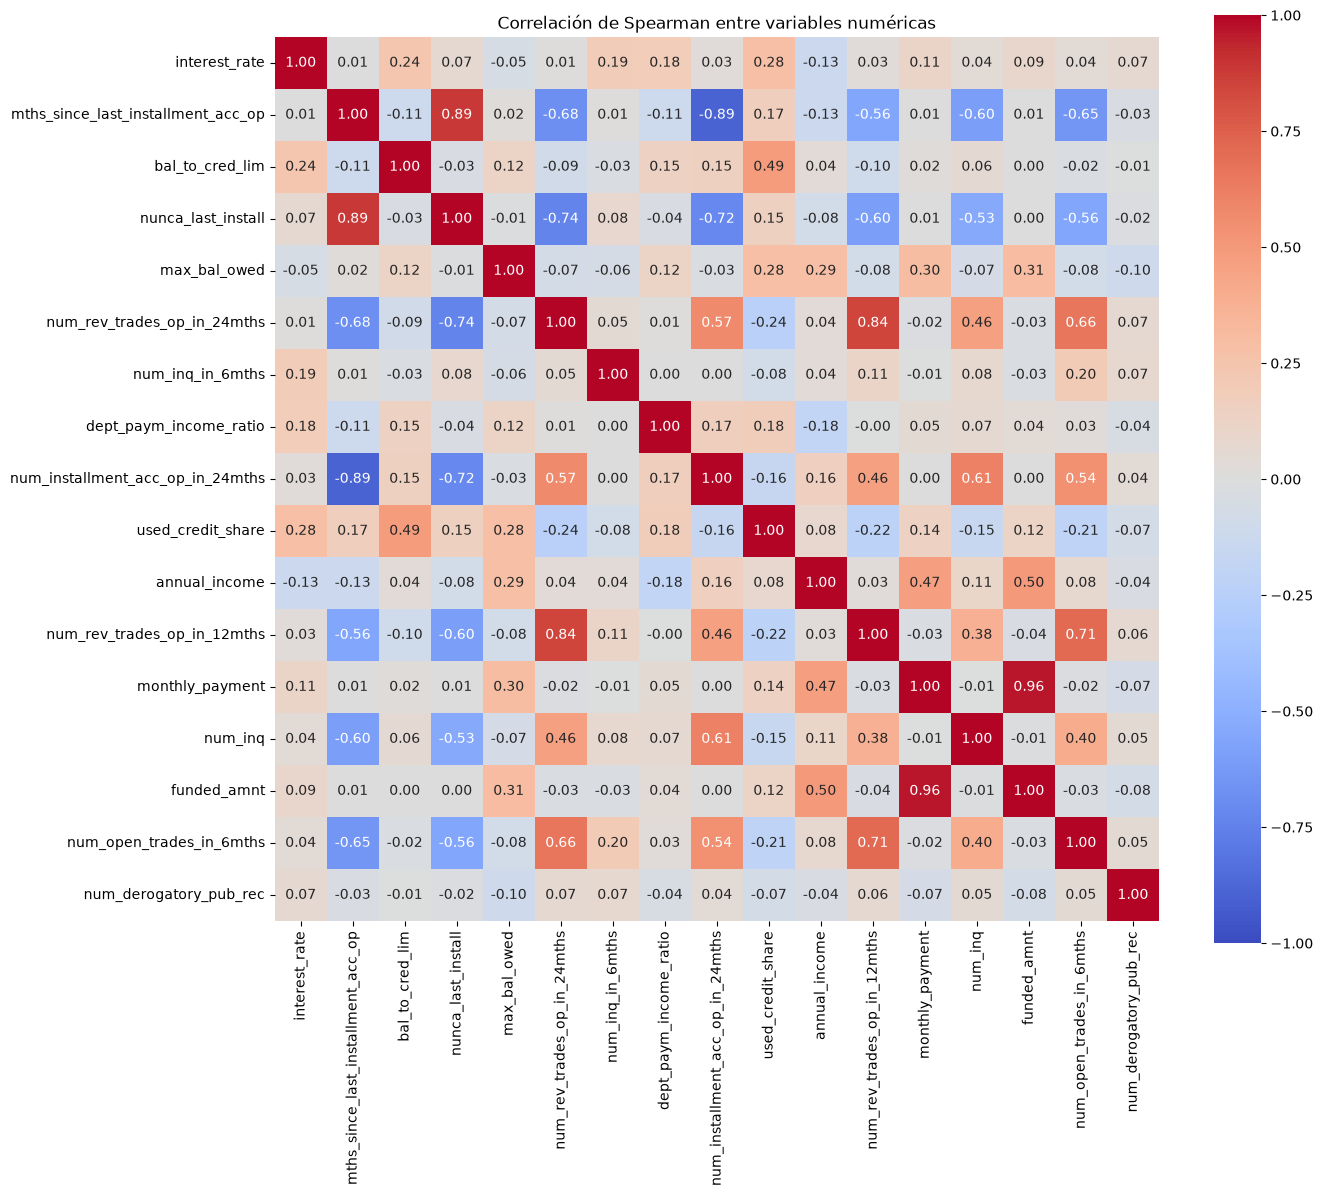

In [45]:
# Usa SOLO el set que sobrevivió al filtro de IV (sin princ_rec, interest_rec, etc. por leakage)
variables_finales = [
    'interest_rate', 'mths_since_last_installment_acc_op', 'bal_to_cred_lim',
    'nunca_last_install', 'max_bal_owed', 'num_rev_trades_op_in_24mths',
    'num_inq_in_6mths', 'dept_paym_income_ratio', 'num_installment_acc_op_in_24mths',
    'used_credit_share', 'annual_income', 'num_rev_trades_op_in_12mths',
    'monthly_payment', 'num_inq', 'funded_amnt', 'num_open_trades_in_6mths',
    'num_derogatory_pub_rec'
]

variables_finales = rank_pd[rank_pd['IV']>0.01].index.to_list()

corr_matrix = train_df[variables_finales].corr(method='spearman')

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True)
plt.title('Correlación de Spearman entre variables numéricas')
plt.tight_layout()
plt.show()

**Tenemos alta correlación en estas variables:** <br>
- num_rev_trades_op_in_12mths **vs.** num_rev_trades_op_in_24mths <br>
- funded_amnt **vs.** monthly_payment <br>
- used_credit_share **vs.** bal_to_cred_lim <br>

In [46]:
# Detectar pares con |correlación| > 0.7 automáticamente
umbral = 0.7
pares_altos = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        valor = corr_matrix.iloc[i, j]
        if abs(valor) > umbral:
            pares_altos.append((corr_matrix.columns[i], corr_matrix.columns[j], valor))

for par in pares_altos:
    print(par)

('mths_since_last_installment_acc_op', 'nunca_last_install', np.float64(0.8901414222530513))
('mths_since_last_installment_acc_op', 'num_installment_acc_op_in_24mths', np.float64(-0.8931934497159111))
('nunca_last_install', 'num_rev_trades_op_in_24mths', np.float64(-0.7393853792500975))
('nunca_last_install', 'num_installment_acc_op_in_24mths', np.float64(-0.7169634953627053))
('num_rev_trades_op_in_24mths', 'num_rev_trades_op_in_12mths', np.float64(0.8439212129270929))
('num_rev_trades_op_in_12mths', 'num_open_trades_in_6mths', np.float64(0.7133823195654827))
('monthly_payment', 'funded_amnt', np.float64(0.9649895237496686))


**Spearman** en pares detecta correlación bivariada, pero no colinealidad multivariante (ej. una variable que es combinación lineal de otras tres, sin correlacionarse fuertemente con ninguna individualmente). Una vez teniendo el set depurado de pares obvios, ejecutaremos el cálculo de VIF.

Vamos a eliminar de los siguientes pares de variables altamente correlacionadas, al que tiene menor valor de IV:<br>

1. En la 1ra línea se elimina 'nunca_last_install' queda: 'mths_since_last_installment_acc_op'

2. En la 2da línea se elimina: 'num_installment_acc_op_in_24mths' (VI=0.043), se queda 'mths_since_last_installment_acc_op' (VI=0.108)

3. 4. Vamos con la 3ra y 4ta final: COmo 'nunca_last_install' ya fue eliminada, no puede ser comparado con las otras columnas pares entonces, se mantienen.

5. En la 5ta línea, 'num_rev_trades_op_in_24mths' (VI=0.067) todavía no se elimina, entonces, al comparar con 'num_rev_trades_op_in_12mths' (VI=0.025), éste último se elimina.

6. Como 'num_rev_trades_op_in_12mths' ya fue eliminado, entonces 'num_open_trades_in_6mths' se mantiene

7. 'monthly_payment'(VI=0.0228) y 'funded_amnt' (VI=0.0203), se elimina 'funded_amnt'

Por lo tanto se elimina:

- 'nunca_last_install'
- 'num_installment_acc_op_in_24mths'
- 'num_rev_trades_op_in_12mths'
- 'funded_amnt'
</br>


**Contexto:** Entre 'num_rev_trades_op_in_24mths' y num_rev_trades_op_in_12mths. Existe una ventana de 12 meses literalmente contenida dentro de la de 24 meses (redundancia conceptual, no solo estadística).

#### Calcular VIF (Variance of Inflation Factor)

In [47]:
variables_eliminadas = [
    'nunca_last_install',
    'num_installment_acc_op_in_24mths',
    'num_rev_trades_op_in_12mths',
    'funded_amnt'
]

variables_finales_depuradas = [var for var in variables_finales if var not in variables_eliminadas]

In [48]:
X = train_df[variables_finales_depuradas].dropna()
vif_data = pd.DataFrame()
vif_data['variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values('VIF', ascending=False)

,variable,VIF
4,num_rev_trades_op_in_24mths,1.968722
11,num_open_trades_in_6mths,1.804116
1,mths_since_last_installment_acc_op,1.801484
7,used_credit_share,1.623058
2,bal_to_cred_lim,1.465094
10,num_inq,1.286789
0,interest_rate,1.242150
3,max_bal_owed,1.232759
5,num_inq_in_6mths,1.160695
9,monthly_payment,1.151040


Como no existe valores VIF > 5-10 entonces se mantienen todas las 13 variables. Ahora procederemos a realizar un WoE-Enconging (reemplazar cada valor del dataset por su WOE correspondiente) como feature Engineering que nos permite convertir los grandes rangos que tienen centinelas = 999, en bins para que pueda ser mejor normalizado y linealizado para el logistic regression

### 3.4 WoE Encoding

Agregaremos una codificación de las variables donde se aplicaron análisis Weight of **Evidence(WoE)** para obtner el **Value of Information(VI)**, para que ejecuta con esa parametrización el modelo a construir.

In [ ]:
class WOEEncoder:
    def __init__(self):
        self.mapas = {}      # guarda {variable: {bin: woe}}
        self.bins_def = {}   # guarda los bins usados por variable
        self.iv_final = {}   # IV recalculado con el set final

    def fit(self, df, target, variables_bins):
        """
        variables_bins: dict {nombre_variable: lista_de_bins_o_None}
                         None = usar qcut automático en deciles
        """
        for col, bins in variables_bins.items():
            df_temp = df[[col, target]].copy()
            if bins is not None:
                df_temp['bin'] = pd.cut(df_temp[col], bins=bins, duplicates='drop')
            else:
                df_temp['bin'] = pd.qcut(df_temp[col], q=10, duplicates='drop')

            grupo = df_temp.groupby('bin', observed=True)[target].agg(['count', 'sum'])
            grupo.columns = ['total', 'malos']
            grupo['buenos'] = grupo['total'] - grupo['malos']

            total_malos = grupo['malos'].sum()
            total_buenos = grupo['buenos'].sum()

            grupo['pct_malos'] = (grupo['malos'] + 0.5) / (total_malos + 0.5)
            grupo['pct_buenos'] = (grupo['buenos'] + 0.5) / (total_buenos + 0.5)
            grupo['woe'] = np.log(grupo['pct_buenos'] / grupo['pct_malos'])
            grupo['iv'] = (grupo['pct_buenos'] - grupo['pct_malos']) * grupo['woe']

            self.mapas[col] = grupo['woe'].to_dict()
            self.bins_def[col] = bins if bins is not None else df_temp['bin'].cat.categories.tolist()
            self.iv_final[col] = grupo['iv'].sum()
        return self

    def transform(self, df):
        df_out = df.copy()
        for col, mapa in self.mapas.items():
            bins = self.bins_def[col]
            df_out[f'{col}_woe'] = pd.cut(df_out[col], bins=bins).map(mapa)
            # fallback para valores de test fuera de rango de train
            df_out[f'{col}_woe'] = df_out[f'{col}_woe'].fillna(0)
        return df_out


# --- Definición de bins por grupo ---
bins_conteo = [-0.1, 0, 1, 2, 5, np.inf]

variables_bins = {
    # zero-inflated
    'num_rev_trades_op_in_24mths': bins_conteo,
    'num_inq_in_6mths': bins_conteo,
    'num_inq': bins_conteo,
    'num_open_trades_in_6mths': bins_conteo,
    'num_derogatory_pub_rec': [-0.1, 0, np.inf],  # casi todo es 0, bin binario basta

    # con sentinela 999
    'mths_since_last_installment_acc_op': [-0.1, 12, 24, 48, 998, np.inf],

    # continuas (qcut automático)
    'interest_rate': None,
    'bal_to_cred_lim': None,
    'max_bal_owed': None,
    'dept_paym_income_ratio': None,
    'used_credit_share': None,
    'annual_income': None,
    'monthly_payment': None,

}

# --- FIT solo con train ---
encoder = WOEEncoder()
encoder.fit(train_df, 'y', variables_bins)

# --- TRANSFORM a train y test con el mismo mapeo ---
train_woe = encoder.transform(train_df)
#test_woe = encoder.transform(test_df)

# Revisar el IV final recalculado (debería ser muy similar al de antes)
pd.Series(encoder.iv_final).sort_values(ascending=False)

interest_rate                         0.446483
mths_since_last_installment_acc_op    0.108283
bal_to_cred_lim                       0.101607
max_bal_owed                          0.083025
num_rev_trades_op_in_24mths           0.067884
num_inq_in_6mths                      0.058585
dept_paym_income_ratio                0.050864
used_credit_share                     0.040082
annual_income                         0.036072
monthly_payment                       0.022842
num_inq                               0.022166
num_open_trades_in_6mths              0.017368
num_derogatory_pub_rec                0.010243
dtype: float64

In [50]:
train_woe.head(2)

,funded_amnt,interest_rate,monthly_payment,grade,home_ownership_status,annual_income,verification_status,loan_purpose,addr_state,dept_paym_income_ratio,...,num_open_trades_in_6mths_woe,num_derogatory_pub_rec_woe,mths_since_last_installment_acc_op_woe,interest_rate_woe,bal_to_cred_lim_woe,max_bal_owed_woe,dept_paym_income_ratio_woe,used_credit_share_woe,annual_income_woe,monthly_payment_woe
0,2500,13.56,84.92,C1,RENT,55000.0,Not Verified,debt_consolidation,NY,18.24,...,0.076026,-0.221507,0.115592,-0.036939,0.721663,0.153001,0.008929,0.416285,-0.092607,0.361250
1,30000,18.94,777.23,D2,MORTGAGE,90000.0,Source Verified,debt_consolidation,LA,26.52,...,-0.135199,-0.221507,0.115592,-0.671334,-0.241604,0.170640,-0.252714,0.305585,0.144640,-0.075009


In [51]:
# Las 13 variables que sobrevivieron IV + Spearman + VIF, ya en su versión WOE
features_finales = [f'{col}_woe' for col in variables_bins.keys()]

X_train = train_woe[features_finales]
y_train = train_woe['y']

#X_test = test_woe[features_finales]
#y_test = test_woe['y']

print(X_train.columns)

Index(['num_rev_trades_op_in_24mths_woe', 'num_inq_in_6mths_woe',
       'num_inq_woe', 'num_open_trades_in_6mths_woe',
       'num_derogatory_pub_rec_woe', 'mths_since_last_installment_acc_op_woe',
       'interest_rate_woe', 'bal_to_cred_lim_woe', 'max_bal_owed_woe',
       'dept_paym_income_ratio_woe', 'used_credit_share_woe',
       'annual_income_woe', 'monthly_payment_woe'],
      dtype='str')


In [52]:
X_train.head()

,num_rev_trades_op_in_24mths_woe,num_inq_in_6mths_woe,num_inq_woe,num_open_trades_in_6mths_woe,num_derogatory_pub_rec_woe,mths_since_last_installment_acc_op_woe,interest_rate_woe,bal_to_cred_lim_woe,max_bal_owed_woe,dept_paym_income_ratio_woe,used_credit_share_woe,annual_income_woe,monthly_payment_woe
0,-0.140300,-0.131561,0.317601,0.076026,-0.221507,0.115592,-0.036939,0.721663,0.153001,0.008929,0.416285,-0.092607,0.361250
1,0.130731,0.187500,0.221279,-0.135199,-0.221507,0.115592,-0.671334,-0.241604,0.170640,-0.252714,0.305585,0.144640,-0.075009
2,0.378316,0.187500,0.317601,-0.063449,0.046282,0.408835,-0.671334,0.721663,0.170640,0.218979,0.305585,-0.067271,0.195871
3,-0.194600,0.187500,0.221279,0.274183,0.046282,0.115592,-0.671334,0.065445,-0.243129,0.070244,-0.186722,0.144640,0.361250
4,0.130731,0.187500,0.317601,-0.135199,0.046282,0.115592,-0.248497,-0.241604,0.170640,-0.252714,0.416285,-0.092607,-0.075009


In [53]:
variables_prohibidas = ['princ_rec', 'interest_rec', 'late_fees_rec',
                         'remaining_princ_for_tot_amnt_fund', 'paym_rec_for_tot_amnt_fund']

assert not any(v in X_train.columns for v in variables_prohibidas), "¡Leakage detectado en X_train!"

### 3.5 Woe Encoding para variables categóricas

Este tipo de prueba es también similar a la prueba chi^2, para hacer un análisis **Weight of Evidence** entre las variables categóricas


In [54]:
train_df['credit_history_length'] = train_df['issue_date_year'] - train_df['earliest_cr_line_year']
#test_df['credit_history_length'] = test_df['issue_date_year'] - test_df['earliest_cr_line_year']

Comprobaremos si hubo inconsistencias en el historial crediticio mediante valores negativos que surjan de la resta

In [55]:
print(train_df['credit_history_length'].describe())

# ¿Hay valores negativos? (originación antes de la primera línea de crédito = imposible)
negativos = train_df[train_df['credit_history_length'] < 0]
print(f"Valores negativos: {len(negativos)}")

count    1.711714e+06
mean     1.636956e+01
std      7.668590e+00
min      0.000000e+00
25%      1.100000e+01
50%      1.500000e+01
75%      2.000000e+01
max      8.300000e+01
Name: credit_history_length, dtype: float64
Valores negativos: 0


### 3.6 Análisis Information Value(IV), Spearman y Variance of Inflation Factor(VIF)

In [56]:
# region_code y loan_term_months: categóricas (pocos niveles)
for col in ['region_code', 'loan_term_months']:
    grupo, iv = calcular_woe_iv(train_df, col, 'y', es_categorica=True)
    print(col, '→ IV:', iv)

# emp_length_num: ya es ordinal 0-10
grupo, iv = calcular_woe_iv(train_df, 'emp_length_num', 'y', bins=None)
print('emp_length_num → IV:', iv)

# credit_history_length: ¿ya la creaste? (issue_date_year - earliest_cr_line_year)
if 'credit_history_length' in train_df.columns:
    grupo, iv = calcular_woe_iv(train_df, 'credit_history_length', 'y', bins=None)
    print('credit_history_length → IV:', iv)
else:
    print('⚠️ Aún no has creado credit_history_length')

region_code → IV: 0.0030575977018753877
loan_term_months → IV: 0.0730323922854482
emp_length_num → IV: 0.004290972420910587
credit_history_length → IV: 0.01070375781108596


Variable | IV  | ¿Pasa el umbral de 0.01?
|--|--|--|
loan_term_months	| 0.0730 |	✅ Sí, y por mucho — superior a <br> - dept_paym_income_ratio (0.051) <br> - used_credit_share (0.040) <br> - annual_income (0.036) de tu set actual
credit_history_length |	0.0107 |	✅ Sí, justo por encima del corte
emp_length_num	| 0.0043 |	❌ No
region_code	| 0.0031 |	❌ No

In [57]:
train_df.drop(columns='emp_length_num', inplace=True)
train_df.drop(columns='region_code', inplace=True)

#### Análisis VIF

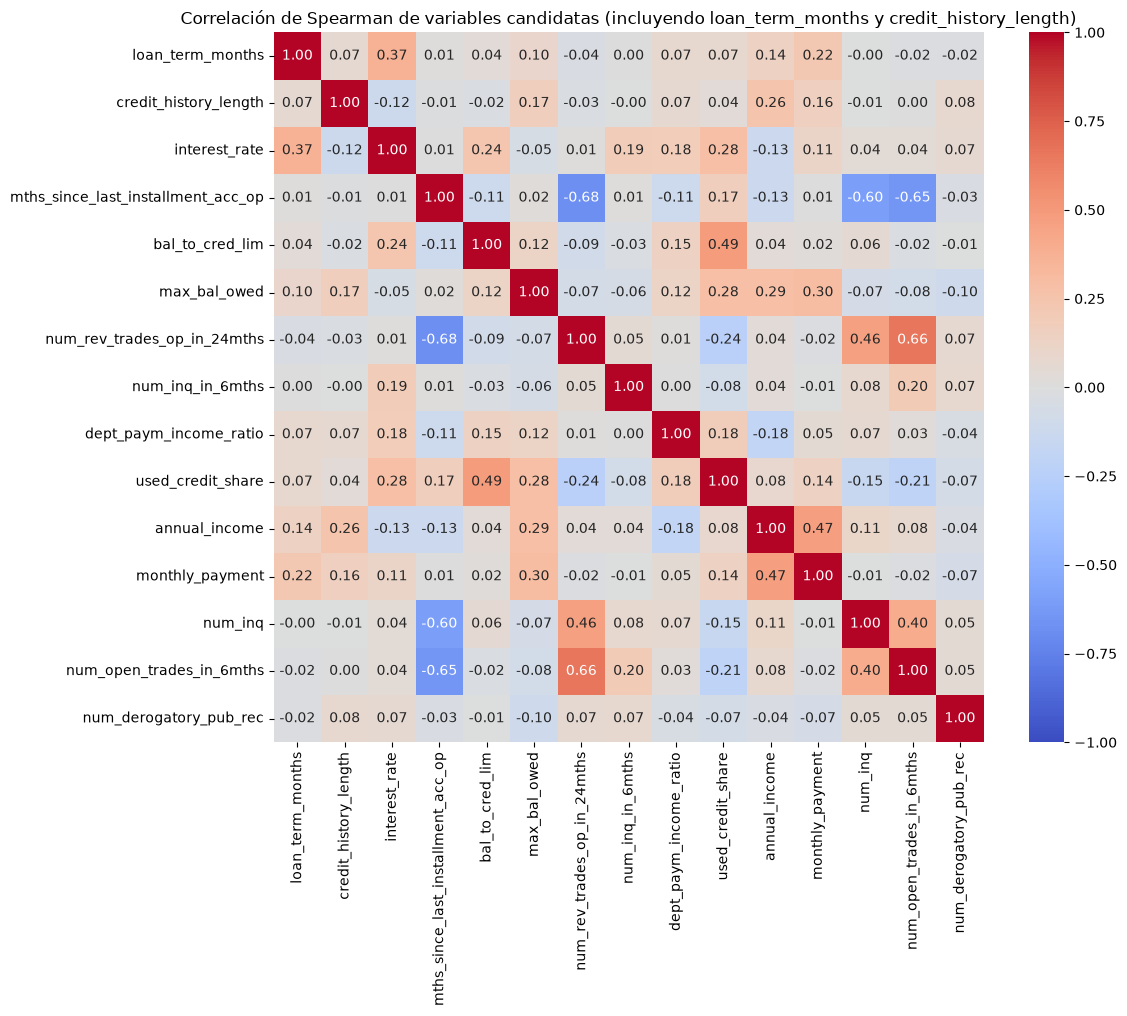

In [58]:
variables_candidatas = ['loan_term_months', 'credit_history_length'] + [
    'interest_rate', 'mths_since_last_installment_acc_op', 'bal_to_cred_lim', 'max_bal_owed',
    'num_rev_trades_op_in_24mths', 'num_inq_in_6mths', 'dept_paym_income_ratio', 'used_credit_share',
    'annual_income', 'monthly_payment', 'num_inq', 'num_open_trades_in_6mths', 'num_derogatory_pub_rec'
]

corr_matrix_ampliada = train_df[variables_candidatas].corr(method='spearman')
# revisa especialmente la fila/columna de loan_term_months y credit_history_length


plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_ampliada, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True)
plt.title('Correlación de Spearman de variables candidatas (incluyendo loan_term_months y credit_history_length)')
plt.tight_layout()
plt.show()

In [59]:
# Detectar pares con |correlación| > 0.7 automáticamente
umbral = 0.7
pares_altos = []
for i in range(len(corr_matrix_ampliada.columns)):
    for j in range(i+1, len(corr_matrix_ampliada.columns)):
        valor = corr_matrix_ampliada.iloc[i, j]
        if abs(valor) > umbral:
            pares_altos.append((corr_matrix_ampliada.columns[i], corr_matrix_ampliada.columns[j], valor))

if pares_altos != []:
    print(pares_altos)
else:
    print("No hay pares con correlación mayor a 0.7")

No hay pares con correlación mayor a 0.7


Tanto gráficamente como analíticamente no hay correlación de pares mayor a 0.7, entre las nuevas variables 'loan_term_months' y 'credit_history_length' y las anteriores

#### Calculamos de nuevo VIF para las nuevas variables

Como no hubo variables depuradas por correlación > 0.7, entonces procederemos con las mismas variables a VIF, <br>cuyo set debe estar por debajo < 5 para ser aceptado

In [60]:
X = train_df[variables_candidatas].dropna()
vif_data = pd.DataFrame()
vif_data['variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values('VIF', ascending=False)

,variable,VIF
6,num_rev_trades_op_in_24mths,1.975483
13,num_open_trades_in_6mths,1.805739
3,mths_since_last_installment_acc_op,1.801496
9,used_credit_share,1.629997
2,interest_rate,1.490381
4,bal_to_cred_lim,1.471317
12,num_inq,1.286978
5,max_bal_owed,1.253399
0,loan_term_months,1.213782
11,monthly_payment,1.169096


In [61]:
variables_bins['loan_term_months'] = None  # NO usar qcut, es solo 2 valores
# en vez de eso, agrégala directo como categórica al encoder:
grupo, iv = calcular_woe_iv(train_df, 'loan_term_months', 'y', es_categorica=True)
grupo, iv

(       total   malos   buenos  pct_malos  pct_buenos      woe        iv
 bin                                                                    
 36   1231272  136415  1094857   0.609614     0.73582  0.18816  0.023747
 60    480442   87358   393084   0.390388     0.26418 -0.39051  0.049286,
 np.float64(0.0730323922854482))

In [62]:
variables_bins['loan_term_months'] = None  # categórica binaria (36/60), trátala aparte
variables_bins['credit_history_length'] = None  # continua, qcut en deciles

### 3.7 Nuevo Encoder y Preprocesador para set: train y test

Se crea un preprocesador que servirá a futuro para procesos MLOPs, que principalmente se encarga de hacer las transformaciones hechas a lo largo de este Notebook, las cuales en algunas se eliminaron columnas, llenaron inconsistenas con llamadas **Transformaciones Tipo A (Fijas)** y las que se aprendieron del train como hacer imputaciones, reemplazar por media o medianas se usa **Transformaciones Tipo B (variables)**

In [78]:
import numpy as np
import pandas as pd


class WOEEncoderV2:
    def __init__(self):
        self.mapas = {}
        self.bins_def = {}
        self.categoricas = []
        self.iv_final = {}

    def fit(self, df, target, variables_bins, categoricas=None):
        self.categoricas = categoricas or []

        for col, bins in variables_bins.items():
            df_temp = df[[col, target]].copy()

            if col in self.categoricas:
                df_temp['bin'] = df_temp[col]
            elif bins is not None:
                df_temp['bin'] = pd.cut(df_temp[col], bins=bins, duplicates='drop')
            else:
                df_temp['bin'] = pd.qcut(df_temp[col], q=10, duplicates='drop')

            grupo = df_temp.groupby('bin', observed=True)[target].agg(['count', 'sum'])
            grupo.columns = ['total', 'malos']
            grupo['buenos'] = grupo['total'] - grupo['malos']

            total_malos = grupo['malos'].sum()
            total_buenos = grupo['buenos'].sum()

            grupo['pct_malos'] = (grupo['malos'] + 0.5) / (total_malos + 0.5)
            grupo['pct_buenos'] = (grupo['buenos'] + 0.5) / (total_buenos + 0.5)
            grupo['woe'] = np.log(grupo['pct_buenos'] / grupo['pct_malos'])
            grupo['iv'] = (grupo['pct_buenos'] - grupo['pct_malos']) * grupo['woe']

            self.mapas[col] = grupo['woe'].to_dict()
            if col in self.categoricas:
                self.bins_def[col] = None
            elif bins is not None:
                self.bins_def[col] = bins
            else:
                self.bins_def[col] = pd.IntervalIndex(df_temp['bin'].cat.categories)
            self.iv_final[col] = grupo['iv'].sum()
        return self

    def transform(self, df):
        df_out = df.copy()
        for col, mapa in self.mapas.items():
            if col in self.categoricas:
                codificado = df_out[col].map(mapa)
            else:
                binned = pd.cut(df_out[col], bins=self.bins_def[col])
                codificado = binned.astype(object).map(mapa)
            df_out[f'{col}_woe'] = pd.to_numeric(codificado, errors='coerce').astype('float64').fillna(0.0)
        return df_out


class PreprocesadorECL:
    def __init__(self):
        self.parametros = {}
        self.woe_encoder = WOEEncoderV2()
        self.categoricas = ['loan_term_months']
        self.variables_bins = {
            'num_rev_trades_op_in_24mths': [-0.1, 0, 1, 2, 5, np.inf],
            'num_inq_in_6mths': [-0.1, 0, 1, 2, 5, np.inf],
            'num_inq': [-0.1, 0, 1, 2, 5, np.inf],
            'num_open_trades_in_6mths': [-0.1, 0, 1, 2, 5, np.inf],
            'num_derogatory_pub_rec': [-0.1, 0, np.inf],
            'mths_since_last_installment_acc_op': [-0.1, 12, 24, 48, 998, np.inf],
            'interest_rate': None,
            'bal_to_cred_lim': None,
            'max_bal_owed': None,
            'dept_paym_income_ratio': None,
            'used_credit_share': None,
            'annual_income': None,
            'monthly_payment': None,
            'loan_term_months': None,
            'credit_history_length': None,
        }

    def _features_fijas(self, df):
        """Tipo A: reglas fijas, idénticas para train y test."""
        df = df.copy()
        df['credit_history_length'] = (df['issue_date_year'] - df['earliest_cr_line_year']).clip(lower=0)
        df['mths_since_last_installment_acc_op'] = df['mths_since_last_installment_acc_op'].fillna(999)
        for col in ['num_open_trades_in_6mths', 'num_rev_trades_op_in_24mths', 'num_inq']:
            df[col] = df[col].fillna(0)
        df['annual_income'] = df['annual_income'].clip(upper=1_000_000)
        return df

    def fit(self, train_df, target='y'):
        train = self._features_fijas(train_df)

        # Tipo B: parámetros aprendidos solo de train
        self.parametros['mediana_max_bal_owed'] = train['max_bal_owed'].median()
        self.parametros['media_bal_to_cred_lim'] = train['bal_to_cred_lim'].mean()

        train['max_bal_owed'] = train['max_bal_owed'].fillna(self.parametros['mediana_max_bal_owed'])
        train['bal_to_cred_lim'] = train['bal_to_cred_lim'].fillna(self.parametros['media_bal_to_cred_lim'])

        self.woe_encoder.fit(train, target, self.variables_bins, categoricas=self.categoricas)
        return self

    def transform(self, df):
        df = self._features_fijas(df)
        df['max_bal_owed'] = df['max_bal_owed'].fillna(self.parametros['mediana_max_bal_owed'])
        df['bal_to_cred_lim'] = df['bal_to_cred_lim'].fillna(self.parametros['media_bal_to_cred_lim'])
        return self.woe_encoder.transform(df)

    def get_features_finales(self):
        return [f'{col}_woe' for col in self.variables_bins]

Uso del Proprocesador para hacer las transformaciones Tipo A y Tipo B

In [79]:
# ---------- Uso ----------
prep = PreprocesadorECL()
prep.fit(train_df)

train_woe = prep.transform(train_df)
test_woe = prep.transform(test_df)

features_finales = prep.get_features_finales()
X_train, y_train = train_woe[features_finales], train_woe['y']
X_test, y_test = test_woe[features_finales], test_woe['y']

print('NaN  train/test:', X_train.isna().sum().sum(), X_test.isna().sum().sum())
print('Inf  train/test:', np.isinf(X_train).sum().sum(), np.isinf(X_test).sum().sum())
print('Shapes:', X_train.shape, X_test.shape)

NaN  train/test: 0 0
Inf  train/test: 0 0
Shapes: (1711714, 15) (427929, 15)


In [80]:
print('Tasa default train:', y_train.mean())
print('Tasa default test: ', y_test.mean())

Tasa default train: 0.13073036733940366
Tasa default test:  0.1307296303826102


Aquí se verifica si el split fue estratificado y que la tasa de  'default' en y en train y test sea balanceada

In [81]:
print(((X_train == 0).mean() * 100).round(3))
print(((X_test == 0).mean() * 100).round(3))

num_rev_trades_op_in_24mths_woe           0.0
num_inq_in_6mths_woe                      0.0
num_inq_woe                               0.0
num_open_trades_in_6mths_woe              0.0
num_derogatory_pub_rec_woe                0.0
mths_since_last_installment_acc_op_woe    0.0
interest_rate_woe                         0.0
bal_to_cred_lim_woe                       0.0
max_bal_owed_woe                          0.0
dept_paym_income_ratio_woe                0.0
used_credit_share_woe                     0.0
annual_income_woe                         0.0
monthly_payment_woe                       0.0
loan_term_months_woe                      0.0
credit_history_length_woe                 0.0
dtype: float64
num_rev_trades_op_in_24mths_woe           0.0
num_inq_in_6mths_woe                      0.0
num_inq_woe                               0.0
num_open_trades_in_6mths_woe              0.0
num_derogatory_pub_rec_woe                0.0
mths_since_last_installment_acc_op_woe    0.0
interest_rate_woe  

También verificamos si hubo algún Fallback en el WoE Encoder, se calcula el porcentaje de valores 0 en las columnas test, esto es si algún valor de test_df cayó fuera de los bins "entrenados" en train_df. Aquí el El fillna(0) nunca se activó, por lo tanto el WOE de test viene de bins reales y no de valores neutros.

## 4. Entrenamiento

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

modelo = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
modelo.fit(X_train, y_train)

# 1. Signos de los coeficientes (con WOE = log(%buenos/%malos), todos deberían ser negativos)
coefs = pd.Series(modelo.coef_[0], index=X_train.columns).sort_values()
print(coefs)
print('Intercepto:', modelo.intercept_[0])

# 2. Métricas en train y test
proba_train = modelo.predict_proba(X_train)[:, 1]
proba_test = modelo.predict_proba(X_test)[:, 1]

def ks_stat(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return (tpr - fpr).max()

for nombre, y_real, proba in [('Train', y_train, proba_train), ('Test', y_test, proba_test)]:
    auc = roc_auc_score(y_real, proba)
    print(f'{nombre}: AUC={auc:.4f} | Gini={2*auc-1:.4f} | KS={ks_stat(y_real, proba):.4f}')

interest_rate_woe                        -0.818447
monthly_payment_woe                      -0.749105
num_derogatory_pub_rec_woe               -0.740564
annual_income_woe                        -0.705200
num_inq_in_6mths_woe                     -0.519898
dept_paym_income_ratio_woe               -0.452020
mths_since_last_installment_acc_op_woe   -0.382088
credit_history_length_woe                -0.342650
max_bal_owed_woe                         -0.256238
num_rev_trades_op_in_24mths_woe          -0.226058
num_inq_woe                              -0.191025
bal_to_cred_lim_woe                      -0.180351
loan_term_months_woe                     -0.164380
used_credit_share_woe                    -0.096965
num_open_trades_in_6mths_woe              0.039379
dtype: float64
Intercepto: -0.002476745526978694
Train: AUC=0.7056 | Gini=0.4112 | KS=0.2981
Test: AUC=0.7065 | Gini=0.4129 | KS=0.3005


In [84]:
test_eval = test_woe[['issue_date_year']].copy()
test_eval['y'] = y_test.values
test_eval['proba'] = proba_test

auc_por_anio = test_eval.groupby('issue_date_year').apply(
    lambda g: roc_auc_score(g['y'], g['proba']) if g['y'].nunique() == 2 else np.nan
)
print(auc_por_anio)

issue_date_year
2007    0.636616
2008    0.674050
2009    0.643891
2010    0.662065
2011    0.684595
2012    0.660728
2013    0.683277
2014    0.683039
2015    0.691676
2016    0.686518
2017    0.693311
2018    0.696334
dtype: float64
